# DataProfiler Repo Examples

install the libraries in databricks:

In [1]:
###uncomment if you are using databricks:
# import pyspark.pandas as ps
# library_path = r"/dbfs/....../DataProfiler" 
# ps.set_option("plotting.backend", "matplotlib")
# ps.set_option('display.max_columns', None)
# ps.set_option('compute.max_rows', None)


In [2]:

import sys
import numpy as np
import pandas as pd

import os

print(sys.path)
library_path = os.getcwd()+"\.."
sys.path.append(library_path)
pd.set_option("plotting.backend", "matplotlib")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_columns', None)
print(sys.executable)

%config Completer.use_jedi = False  # For auto-complete 

['C:\\Users\\parsa\\AppData\\Local\\Programs\\Python\\Python310\\python310.zip', 'C:\\Users\\parsa\\AppData\\Local\\Programs\\Python\\Python310\\DLLs', 'C:\\Users\\parsa\\AppData\\Local\\Programs\\Python\\Python310\\lib', 'C:\\Users\\parsa\\AppData\\Local\\Programs\\Python\\Python310', 'c:\\Users\\parsa\\dataprofiler', '', 'c:\\Users\\parsa\\dataprofiler\\lib\\site-packages', 'c:\\Users\\parsa\\dataprofiler\\lib\\site-packages\\win32', 'c:\\Users\\parsa\\dataprofiler\\lib\\site-packages\\win32\\lib', 'c:\\Users\\parsa\\dataprofiler\\lib\\site-packages\\Pythonwin']
c:\Users\parsa\dataprofiler\Scripts\python.exe


### Load data
As a sample, we use sklearn's breast_cancer dataset (slightly modified)

In [3]:
dataset = "HousingData"  # HousingData or  BreastCancer
Xy_train = pd.read_csv(f"Data/{dataset}_TrainData.csv")
Xy_test = pd.read_csv(f"Data/{dataset}_TestData.csv")


####if you are using spark df on databricks:
# Xy_train = ps.read_csv(f"/.../Data/{dataset}_TrainData.csv")# read as pyspark pandas df
# Xy_test = ps.read_csv(f"/f..../{dataset}_TestData.csv")
## Xy_test = spark.read.format("csv").option('header', True).option('inferSchema','true').option("overwriteSchema", "true").option('delimiter', ',').load(f"dbfs:/..s/Data/{dataset}_TestData.csv").pandas_api() # read as spark sql df & convert to pyspark df

X_train = Xy_train.iloc[:, :-1]
X_test = Xy_test.iloc[:, :-1]

feat_names = Xy_train.columns[:-1]

print("shape of Xy_train : ", Xy_train.shape)
print("shape of Xy_test : ", Xy_test.shape)


shape of Xy_train :  (16512, 10)
shape of Xy_test :  (4128, 10)


## A. Data Profiling without segmention

### Create the Object

<div class="alert alert-block alert-info">
    <b> Attributes:</b> <br>
    <i> save_folder_name: str: </i>: 
    The name of the folder used for saving results of profilng (default: <i> Results_of_DataProfiling</i>)
    <br> <br>
    <b>  Main Methods </b>  
    <ul>
        <li><i>describe_data: </i> returns some statistical descriptions for each column of dataframe </li>
        <li><i>plot_hist: </i> plots the histograms of columns</li>
        <li><i>plot_outliers: </i> plots the box plots of columns</li>
        <li><i>correlation_analysis: </i> performs a correlation analysis (Pearson, Kendall, Spearman, Phik) on dataframe. also returns and save the top correlations with absolute value greater than threshold </li>
    </ul> 
</div>    

In [4]:
from DataProfiler import DataProfiler
DataProfiler_obj = DataProfiler()

### 1. General desciptions of features 

,DataType,n_uniques (excl. Nulls),n_Missing,Perc. of Missing,n_Zeros,Perc. of Zeros,1st Most Freq,Perc. of 1st Most Freq,Min,1%,50%,99%,Max
MedInc,float64,10909,0,0.0,0,0.0,1.5,10.0,0.5,1,4,11,15
HouseAge,int64,52,0,0.0,0,0.0,36.0,20.0,1.0,4,29,52,52
AveRooms,float64,14850,875,5.3,0,0.0,3.8,10.0,0.8,3,5,11,142
AveBedrms,float64,11919,20,0.1,0,0.0,1.0,10.0,0.3,1,1,2,34
Population,float64,3628,16,0.1,0,0.0,nan,60.0,3.0,86,"1,165","5,693","35,682"
AveOccup,float64,15261,0,0.0,0,0.0,3.9,10.0,0.7,2,3,5,"1,243"
Latitude,float64,836,0,0.0,0,0.0,34.1,30.0,32.5,33,34,41,42
Longitude,float64,819,0,0.0,0,0.0,-118.3,10.0,-124.3,-123,-118,-116,-114
Target,int64,2,0,0.0,8244,49.9,1.0,60.0,0.0,0,1,1,1


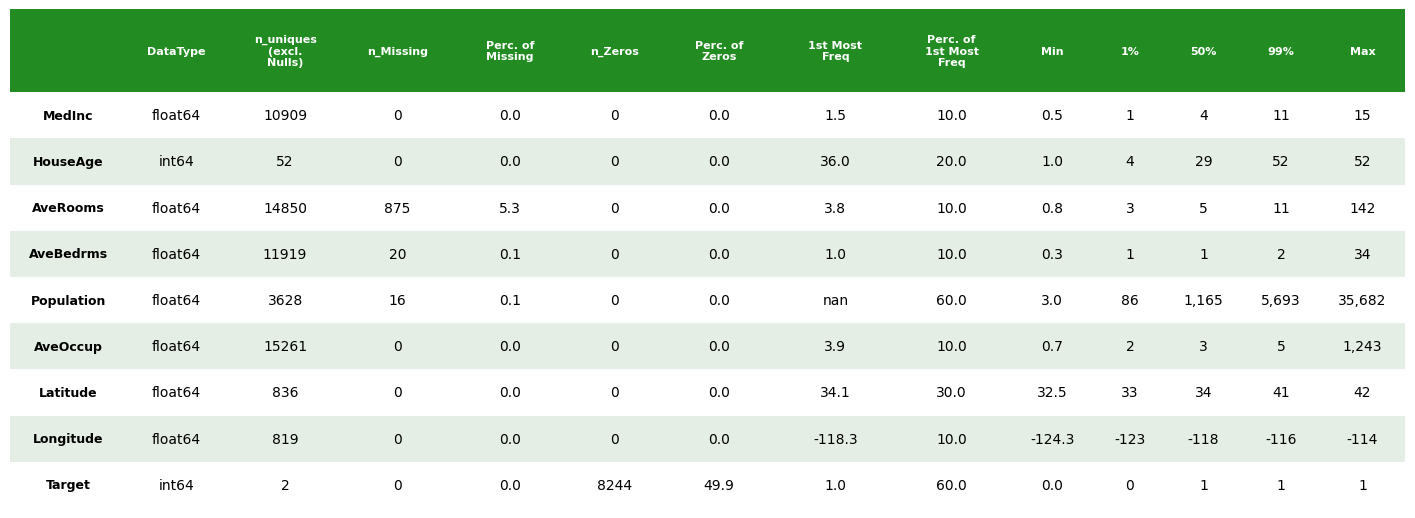

In [5]:
result = DataProfiler_obj.describe_data(Xy_train, save_results=True)
result

### 2. Missing Value Anlaysis

,number_of_missing,percentage_of_missing
AveRooms,875,5.30
AveBedrms,20,0.12
Population,16,0.10


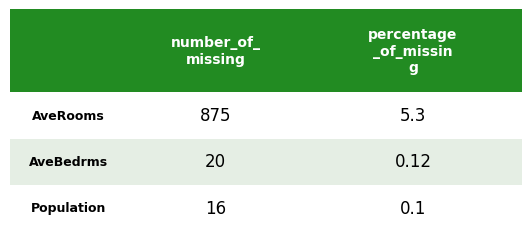

In [6]:

DataProfiler_obj.missing_analysis(Xy_train, save_results=True)

### 3. Correlation Analysis

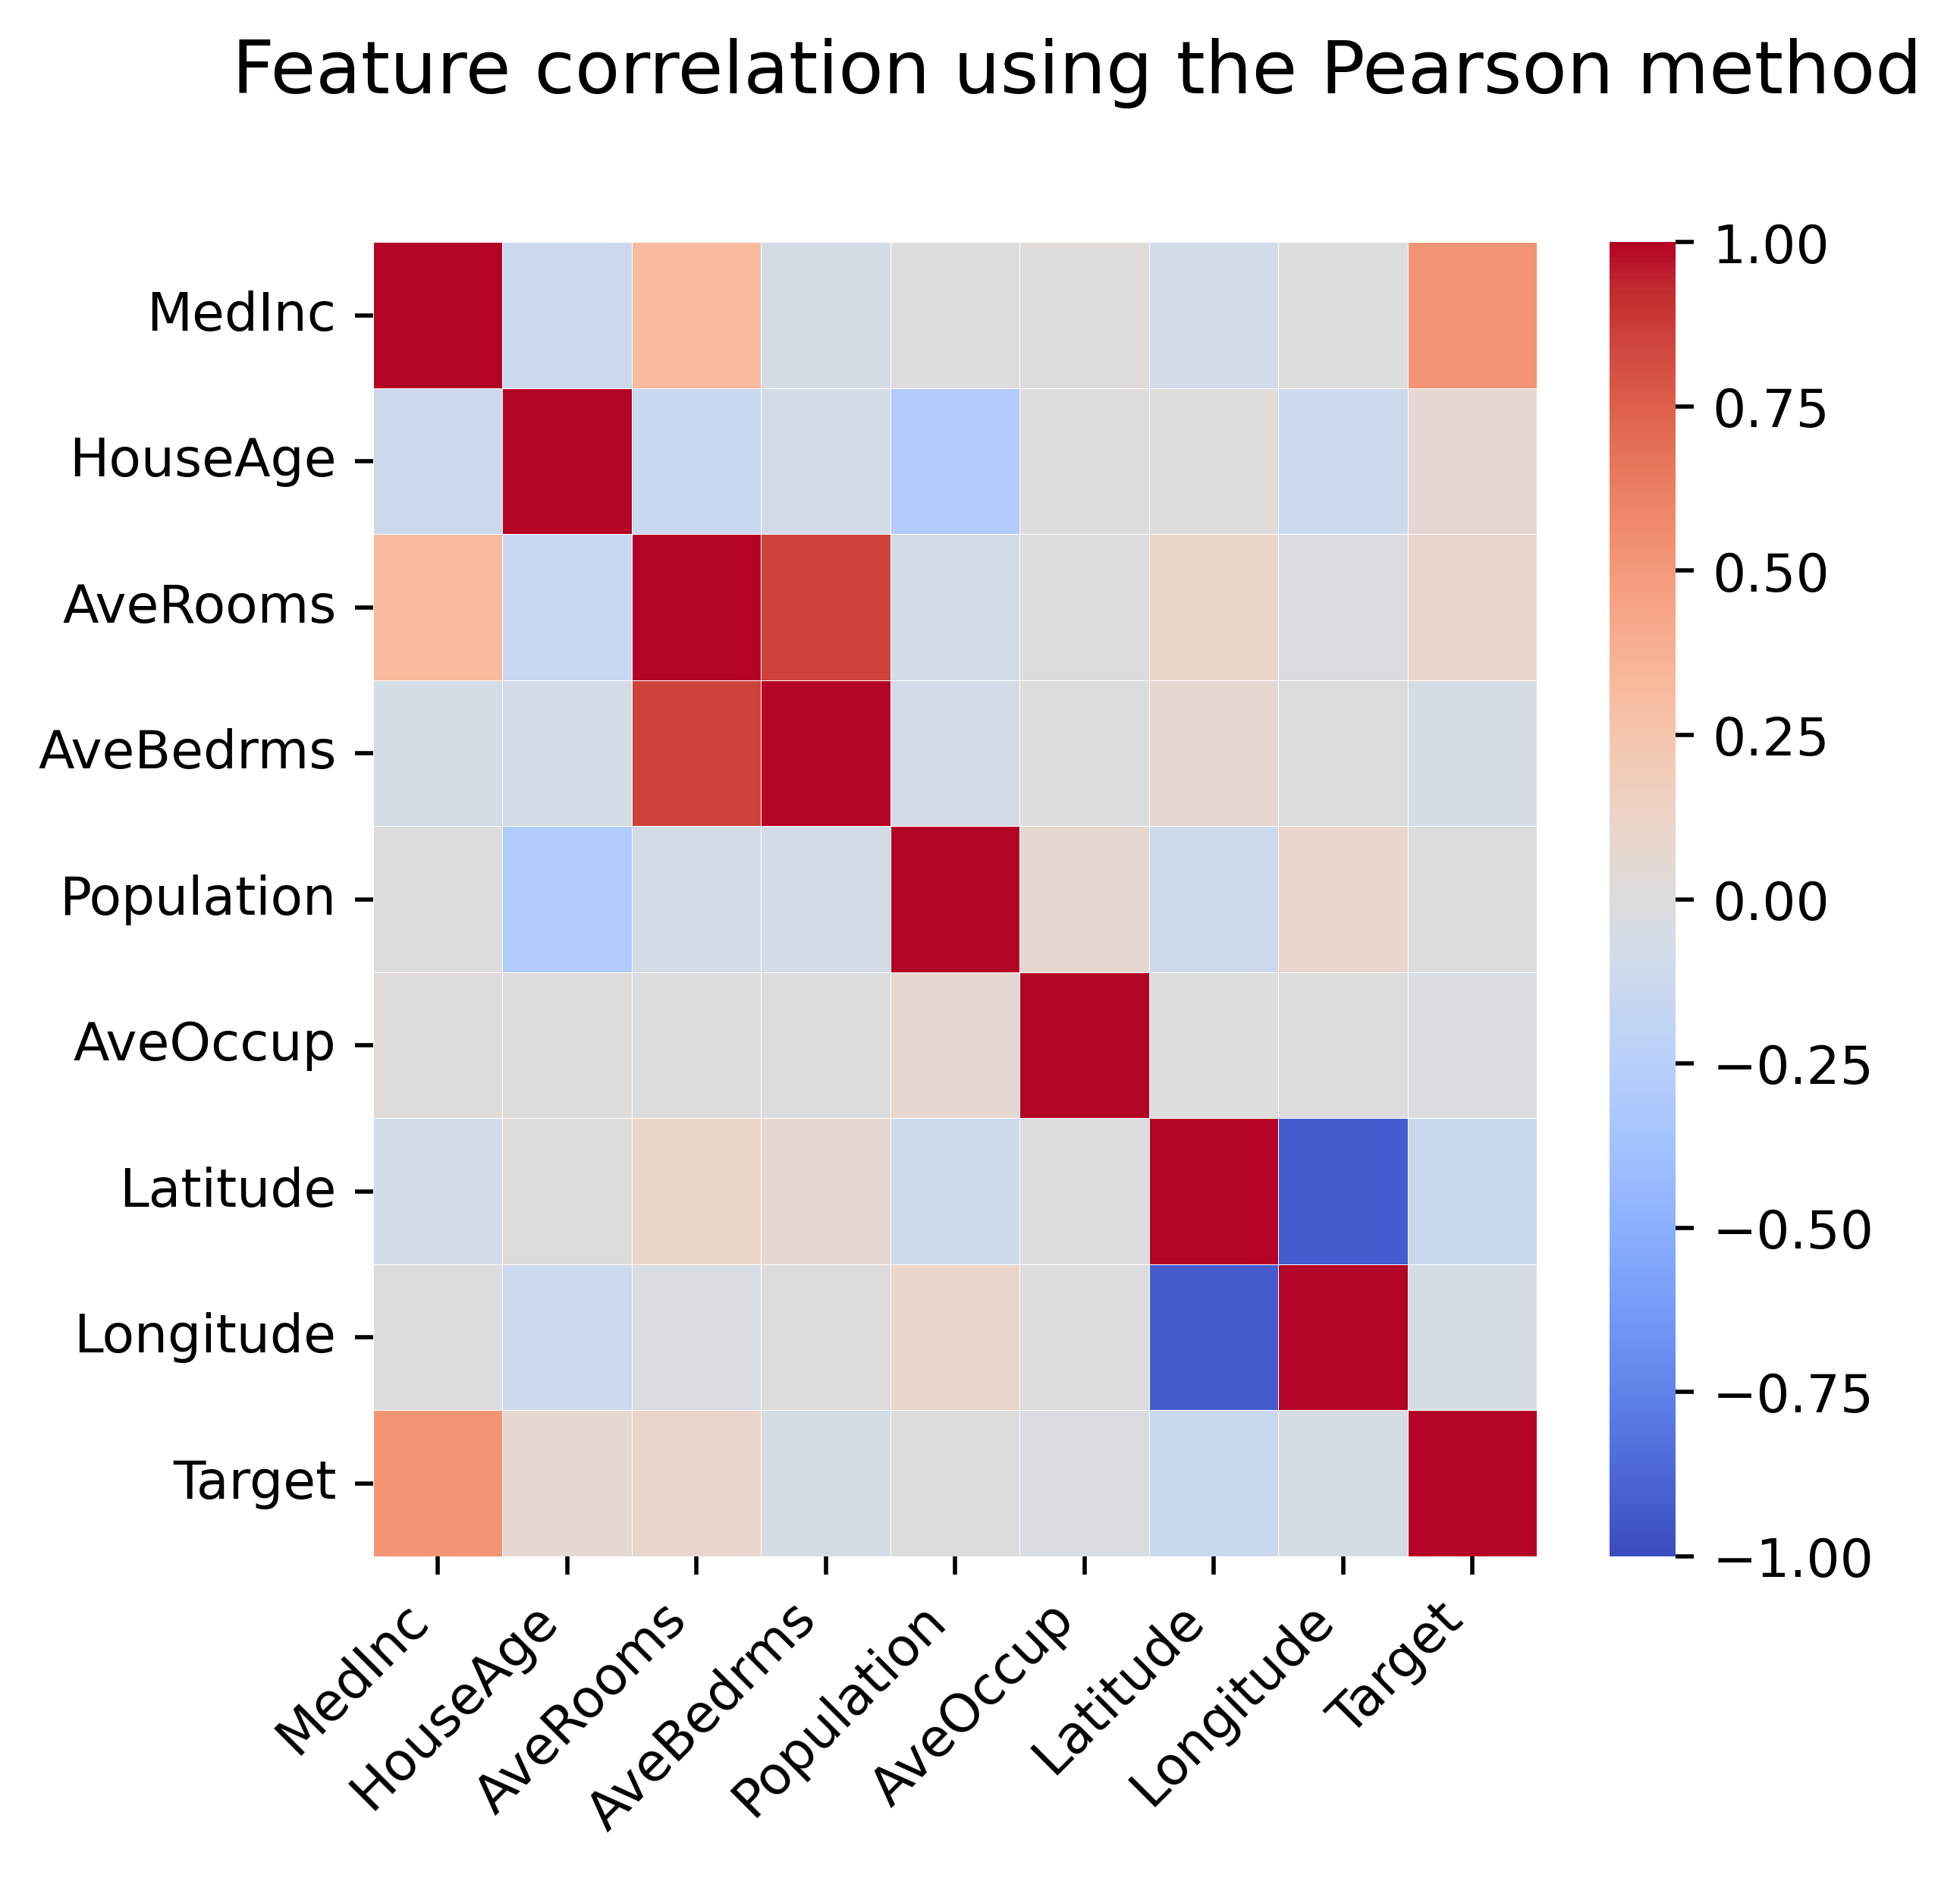

corr_vals without Nulls.shape (9, 9)


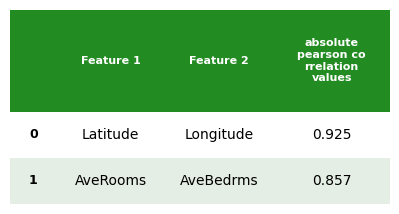

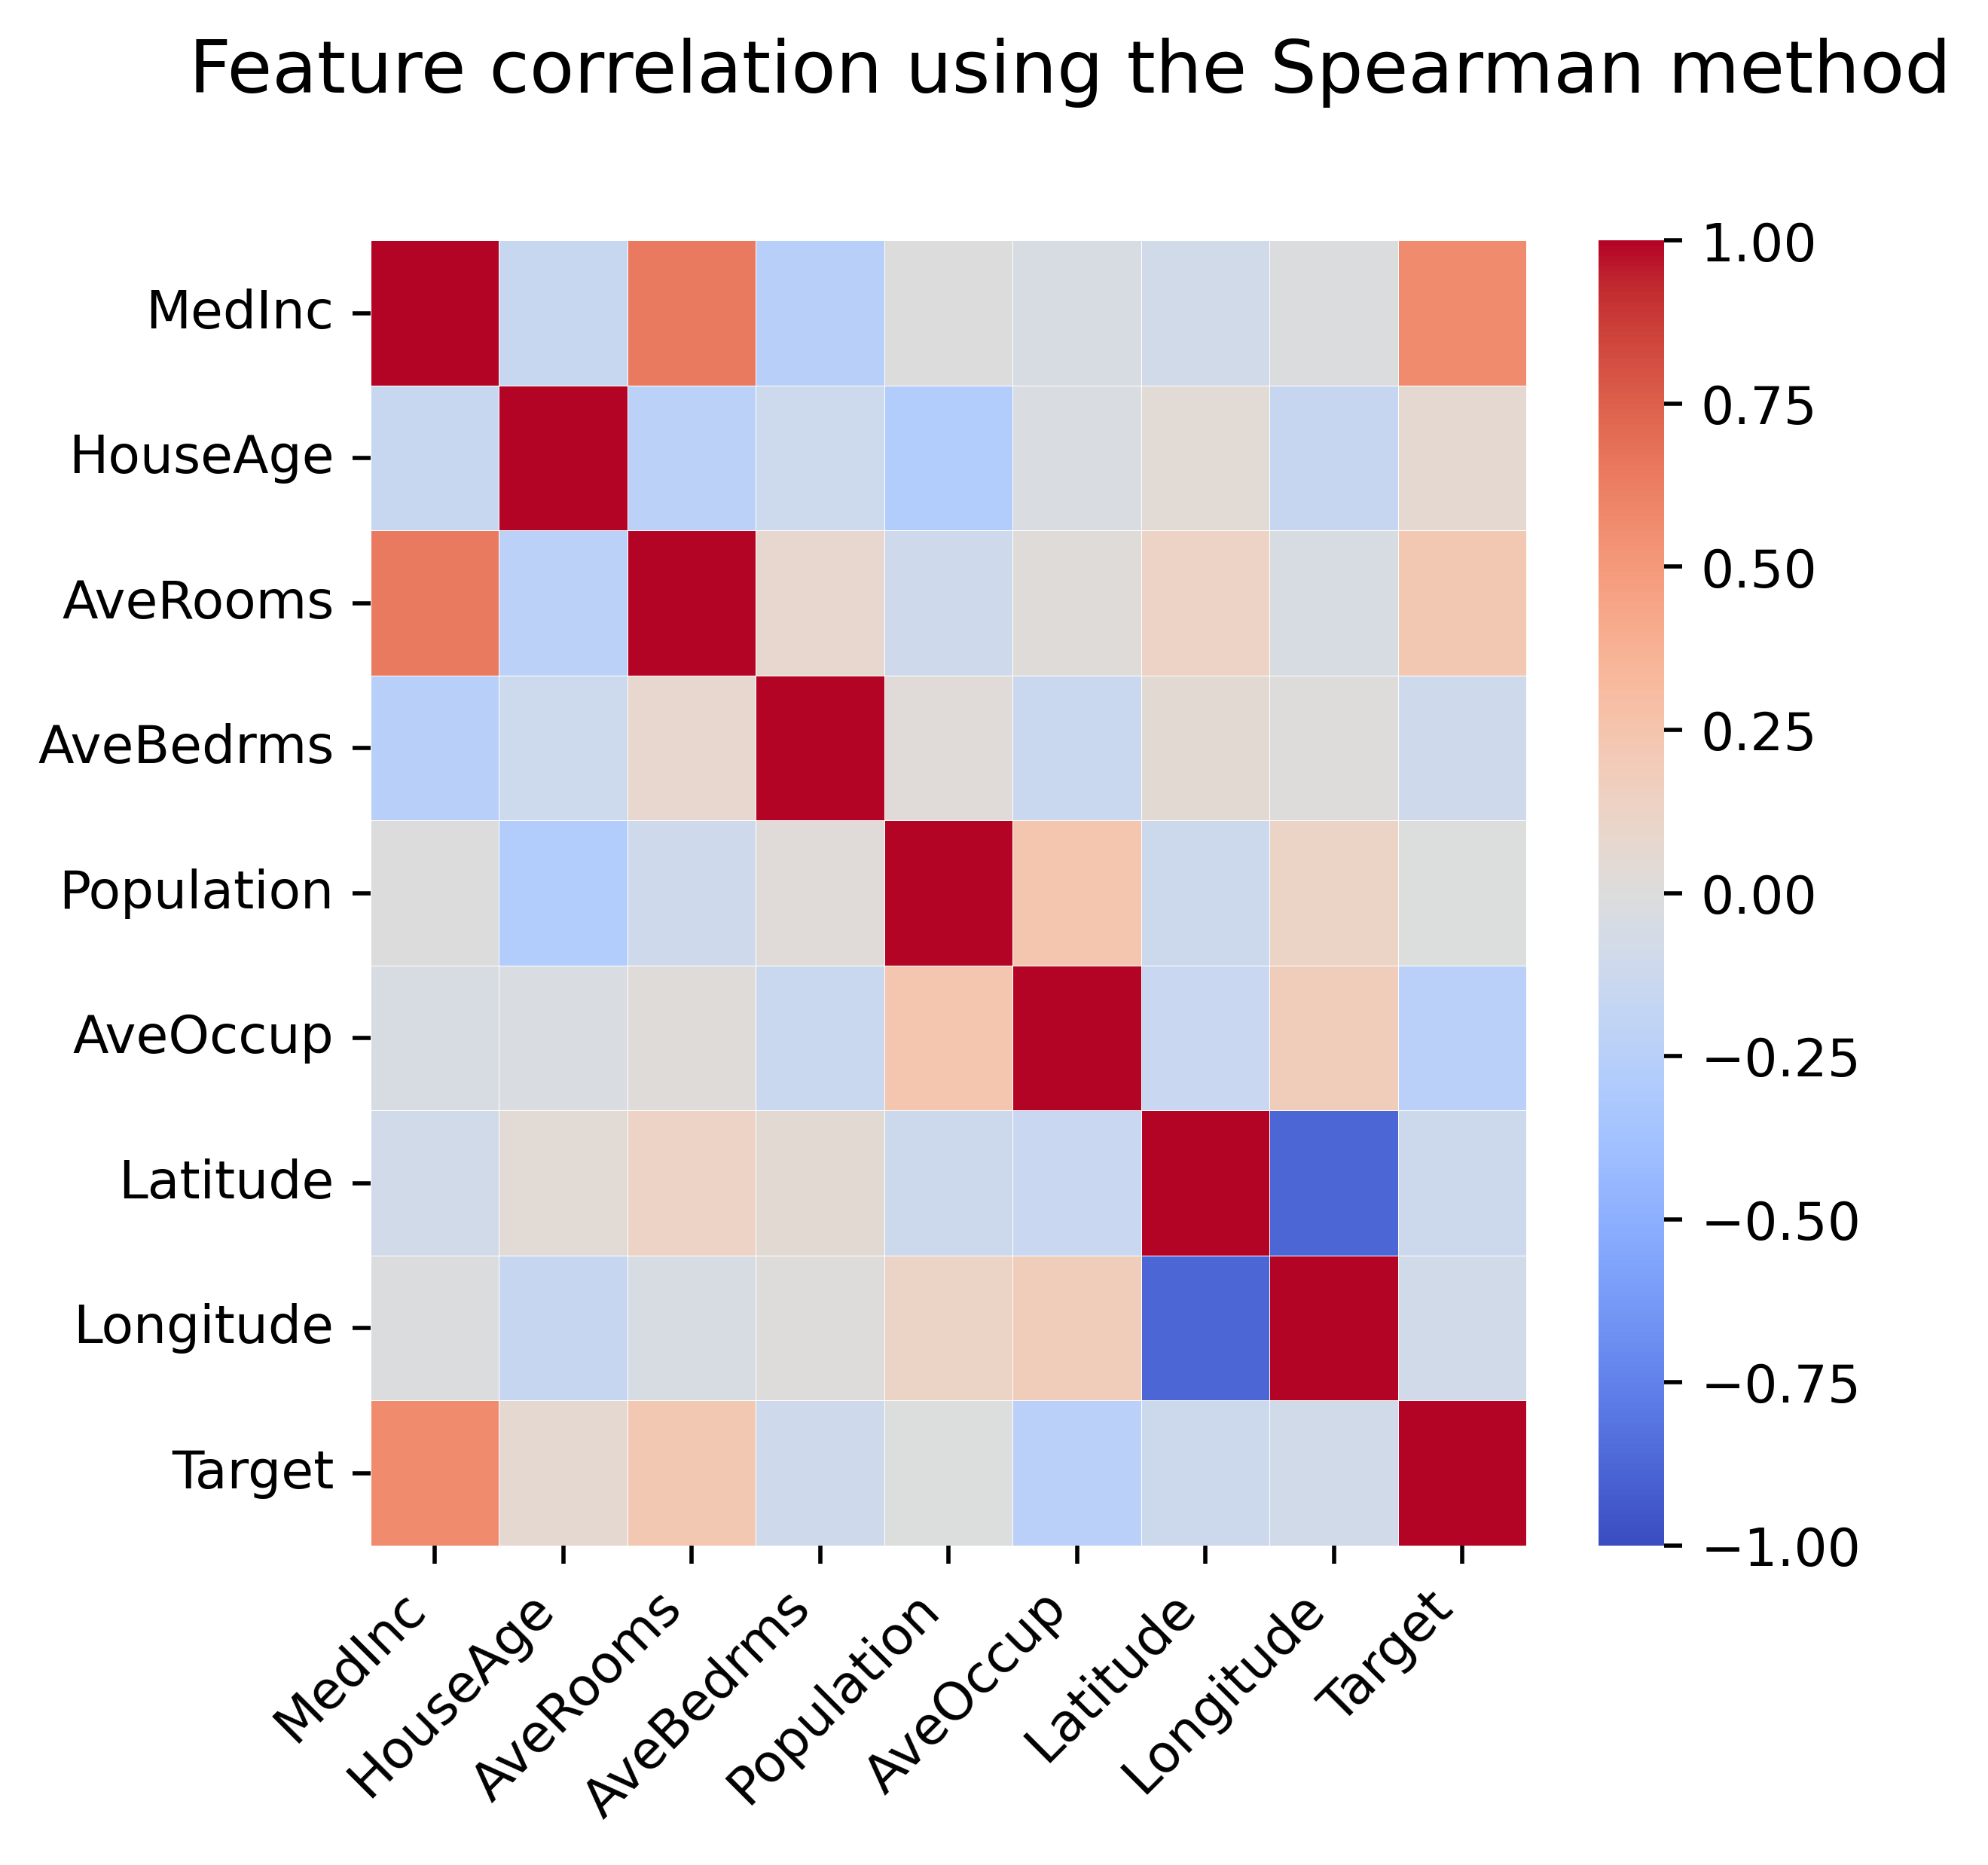

corr_vals without Nulls.shape (9, 9)


,Feature 1,Feature 2,absolute spearman correlation values
0,Latitude,Longitude,0.878


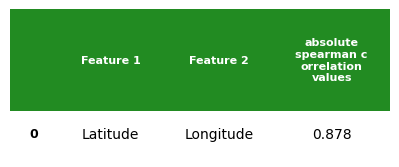

In [7]:
DataProfiler_obj.correlation_analysis(Xy_train, methods=['Pearson','spearman'], save_results=True)

###  4. Plot features

**Distribution Plot (distplot)** - The first thing you want to see when exploring your data is the distribution of your variables. 

**Example 1**: Plot histogram of one set of data

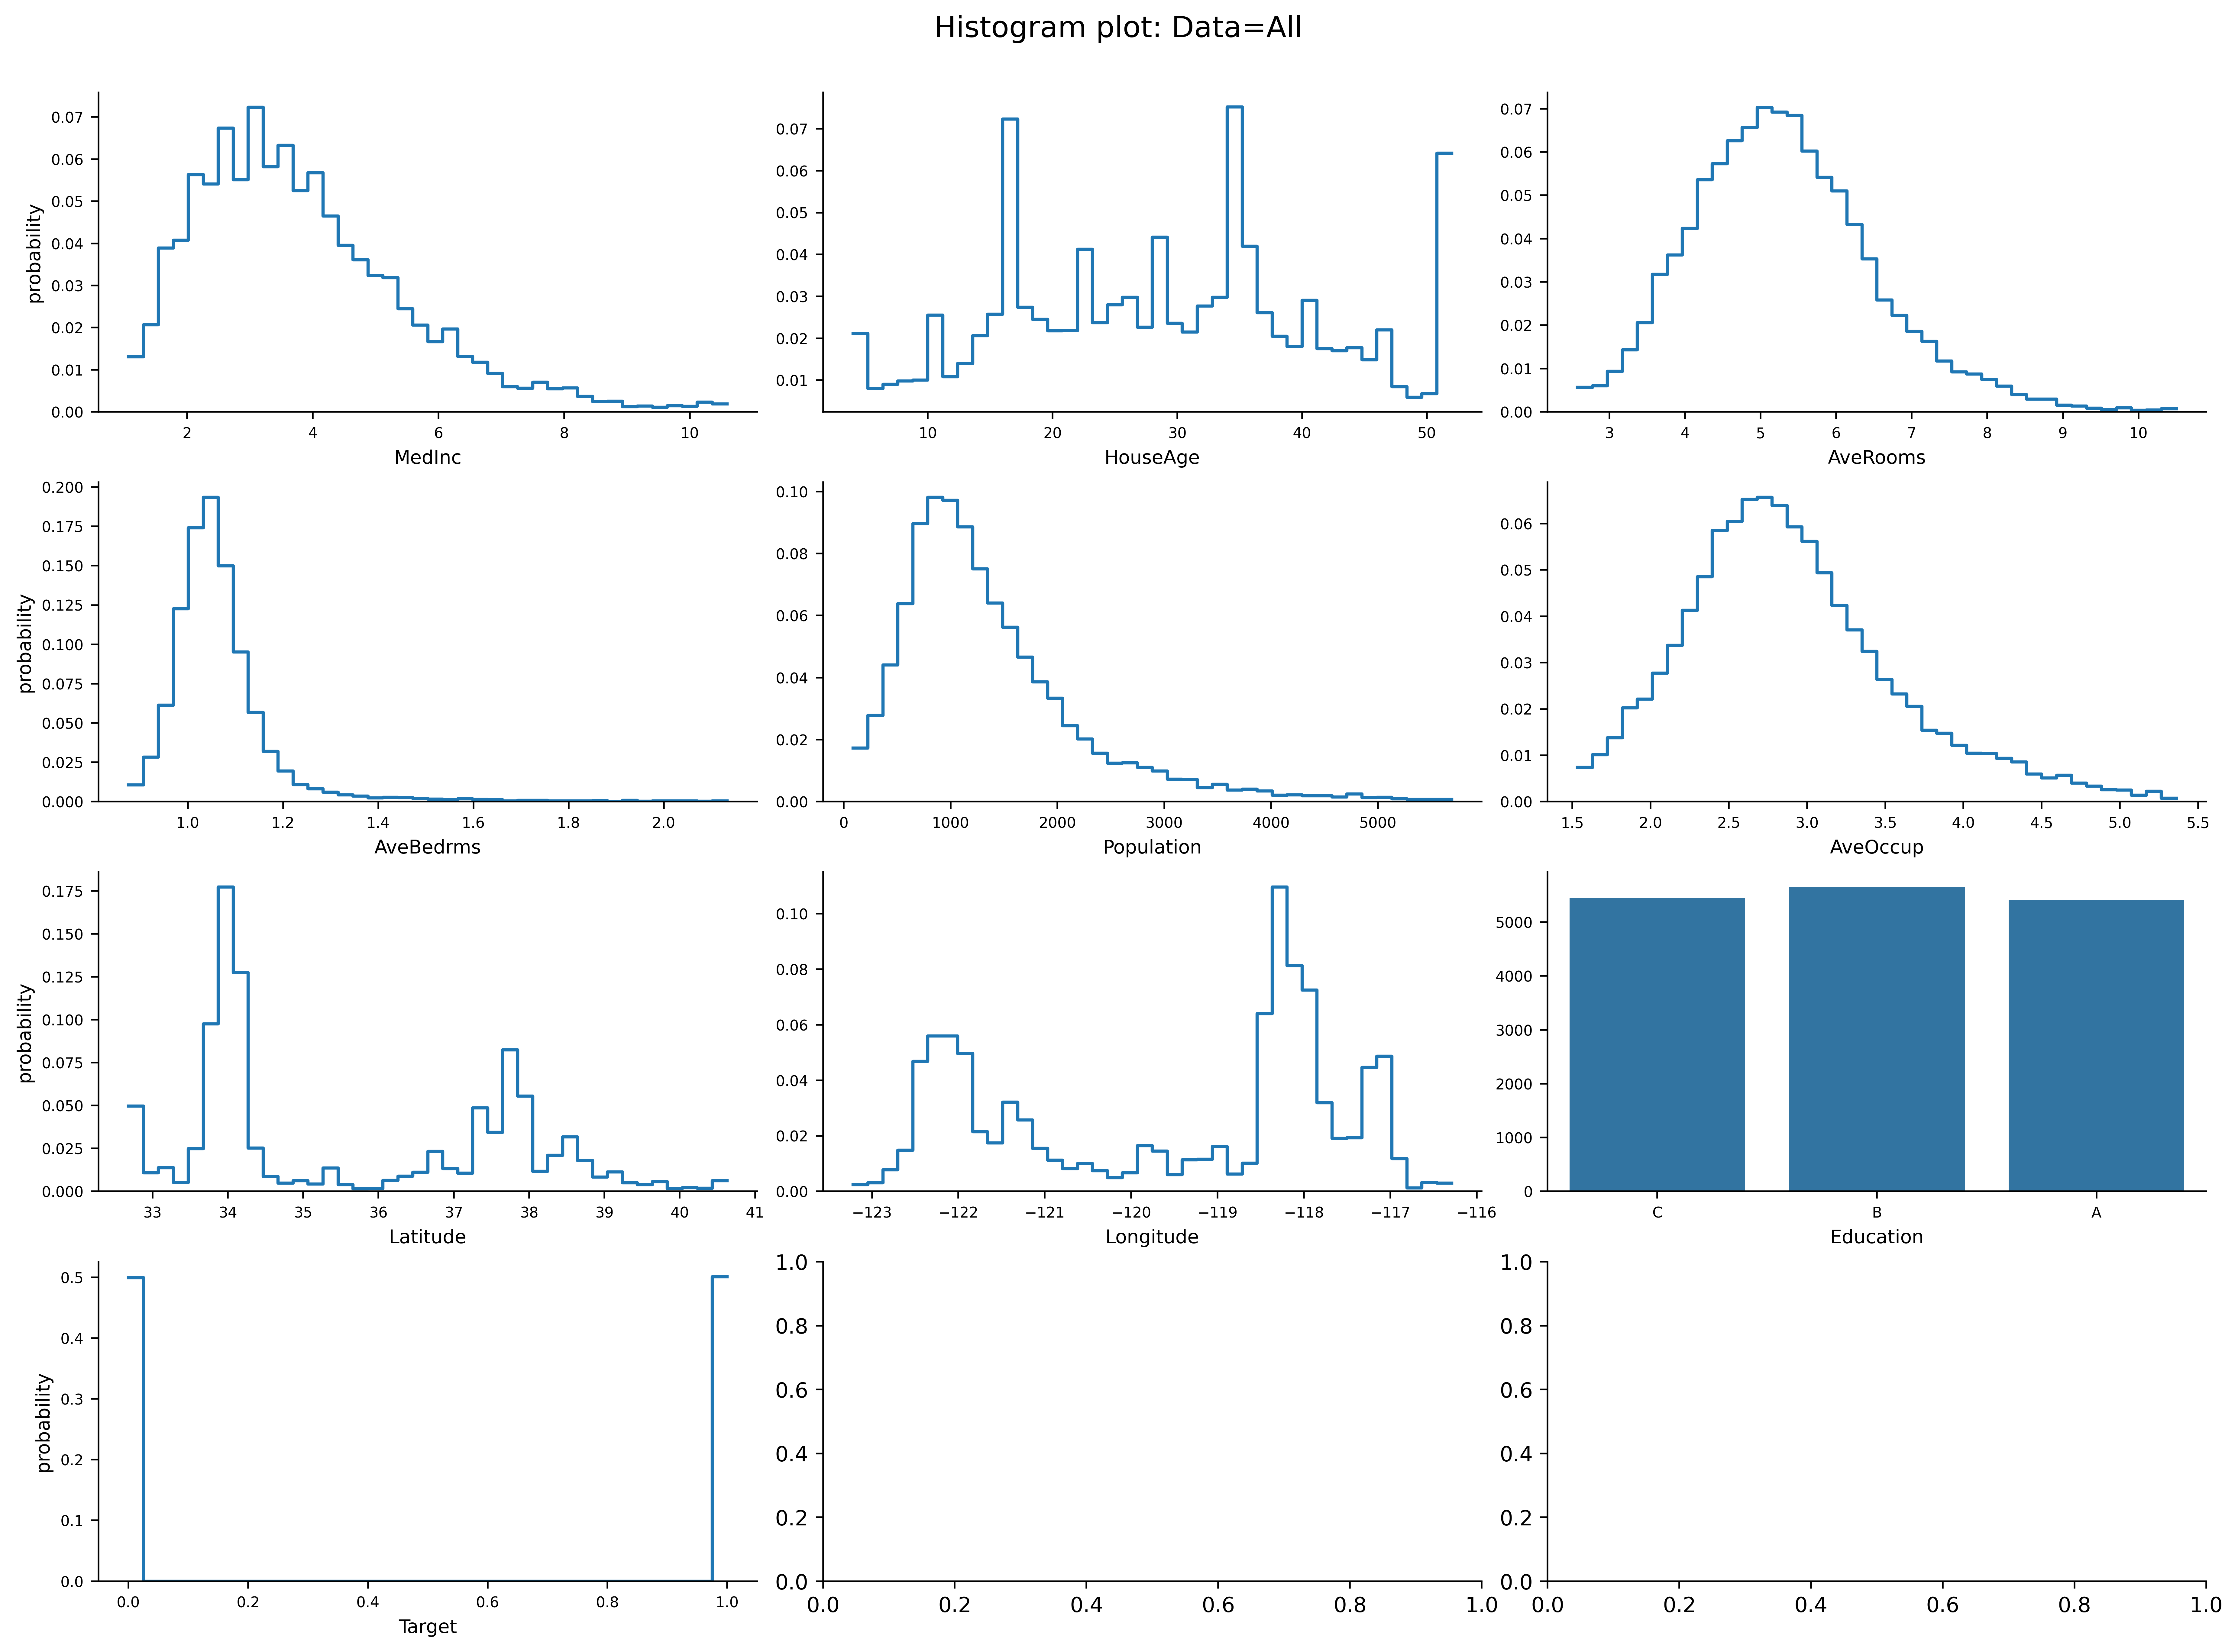

In [8]:
res = DataProfiler_obj.plot_hist(Xy_train)

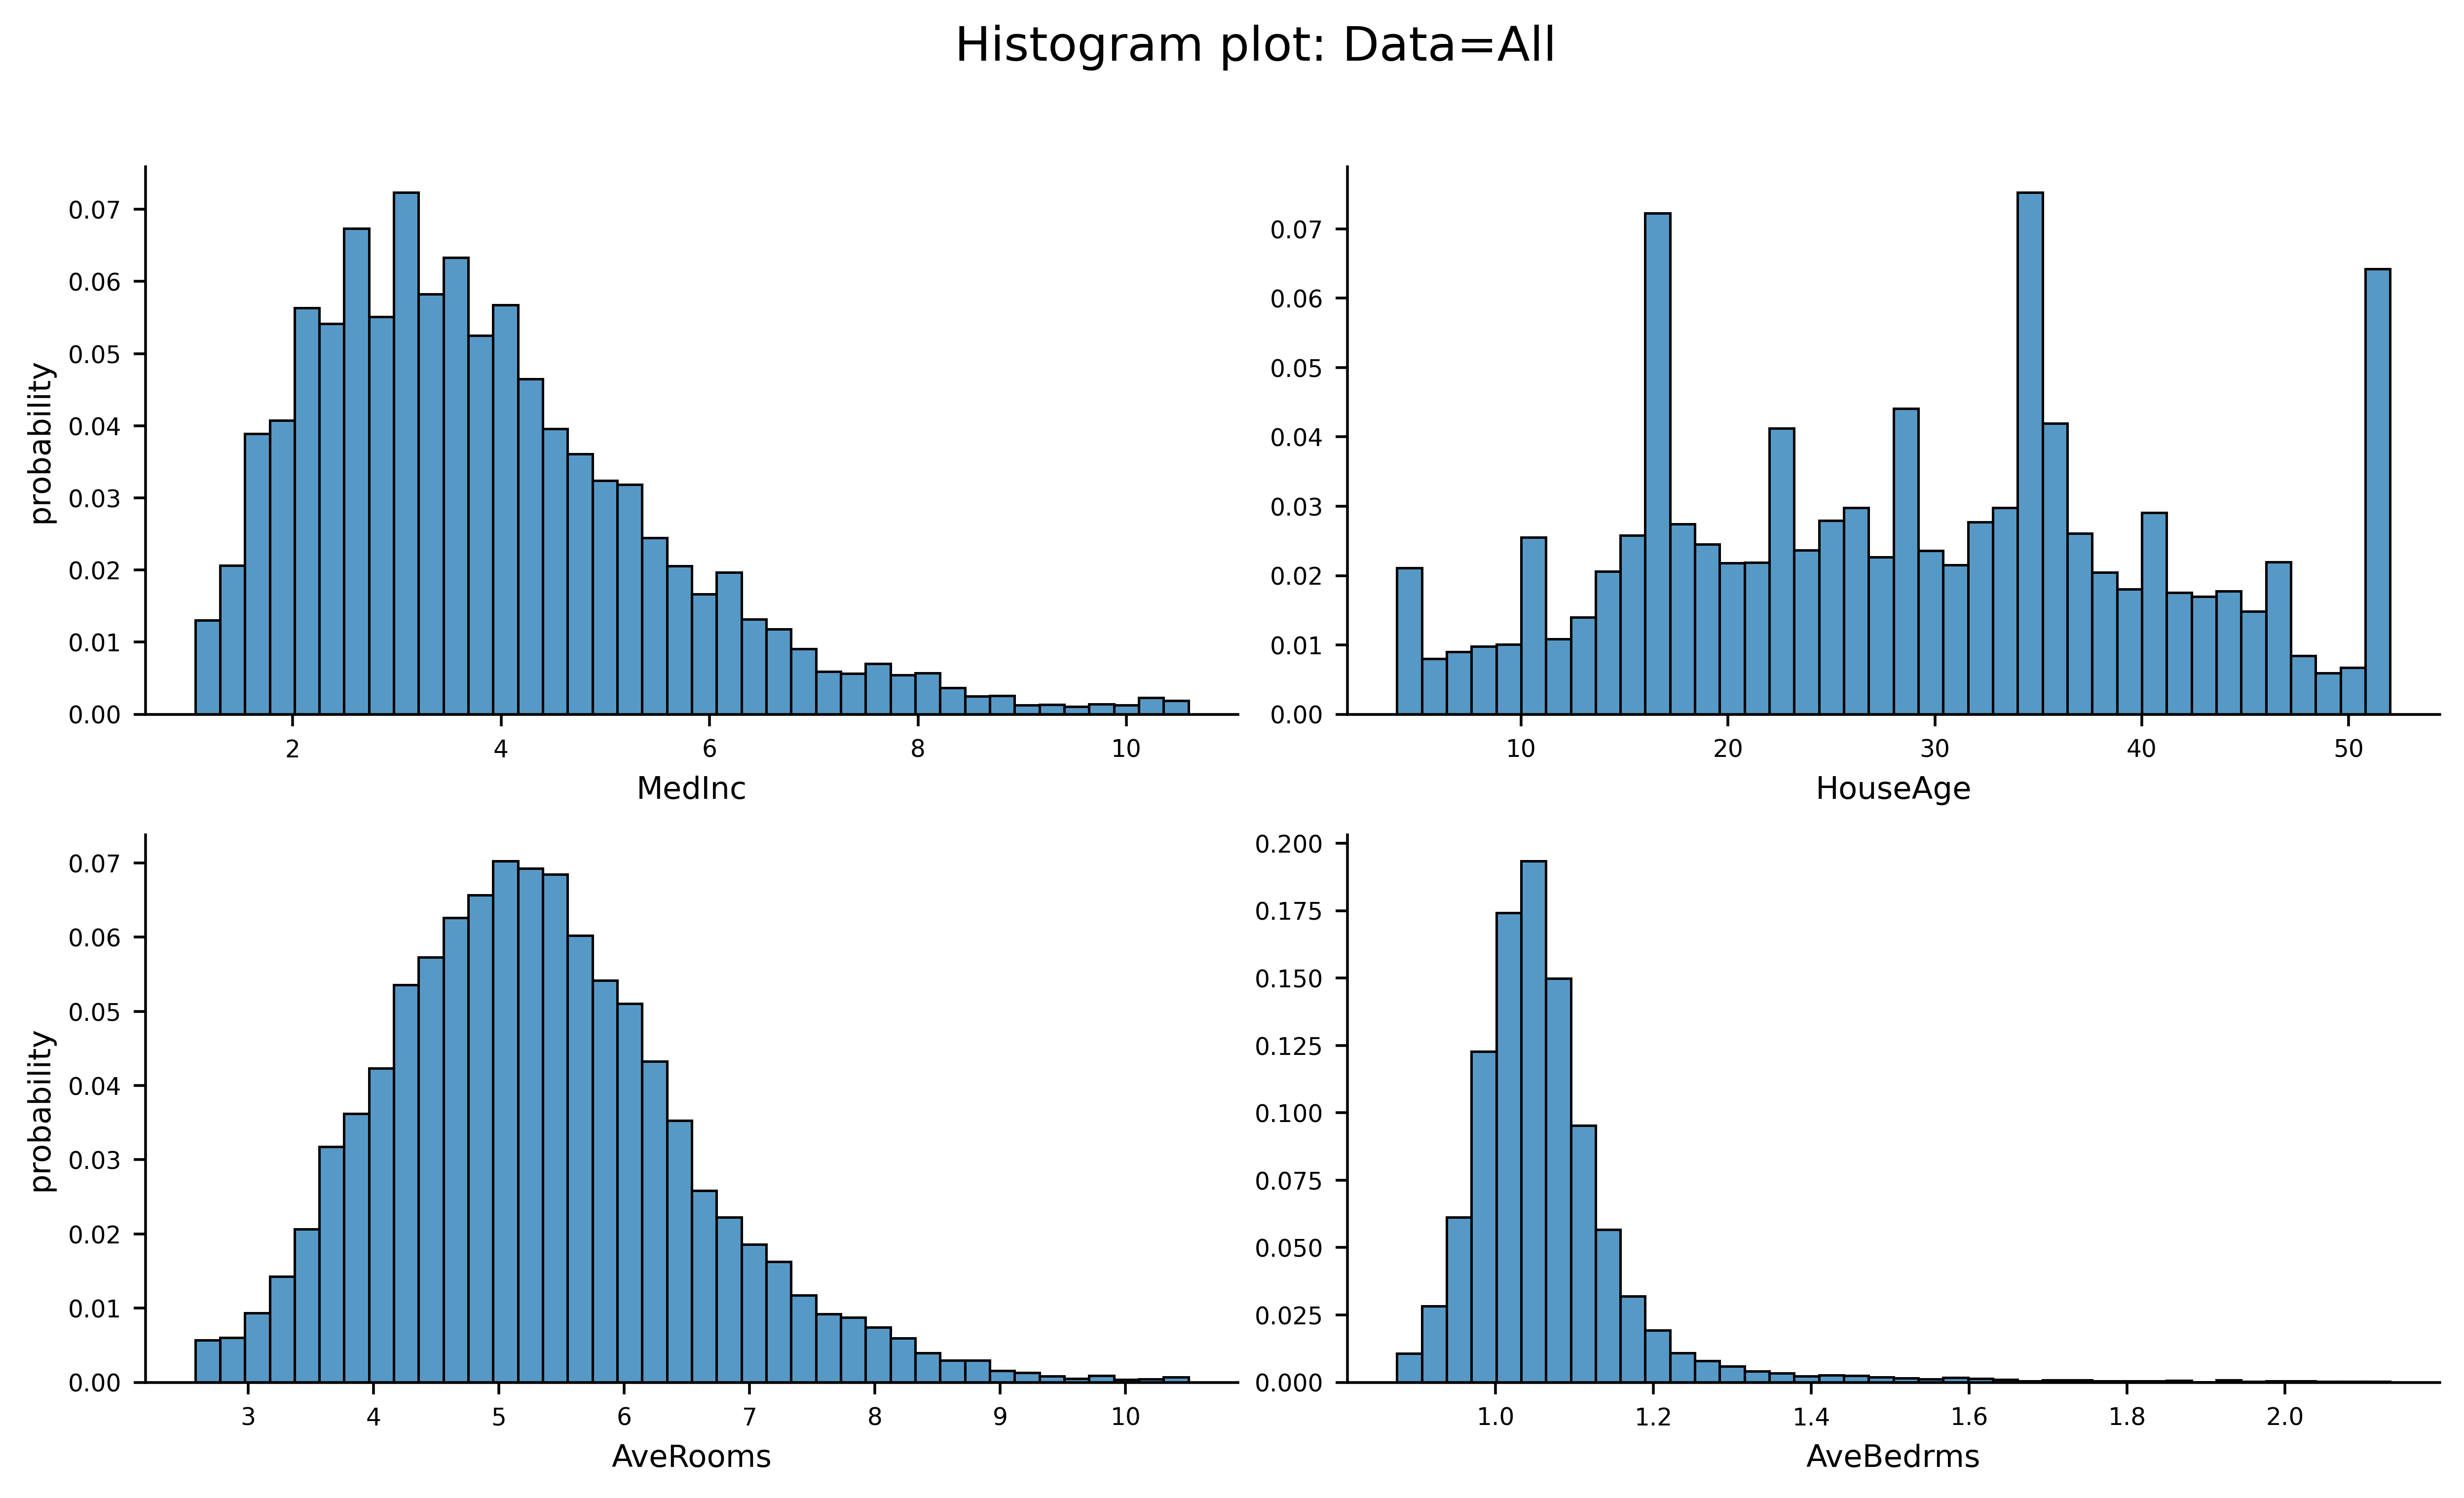

In [9]:
# ********** Adding some arguments **********
res = DataProfiler_obj.plot_hist(Xy_train, selected_features=feat_names[:4], fill=True, element='bars', n_cols=2)

**Example 2**: One set of data; but splitted based on `hul_col`

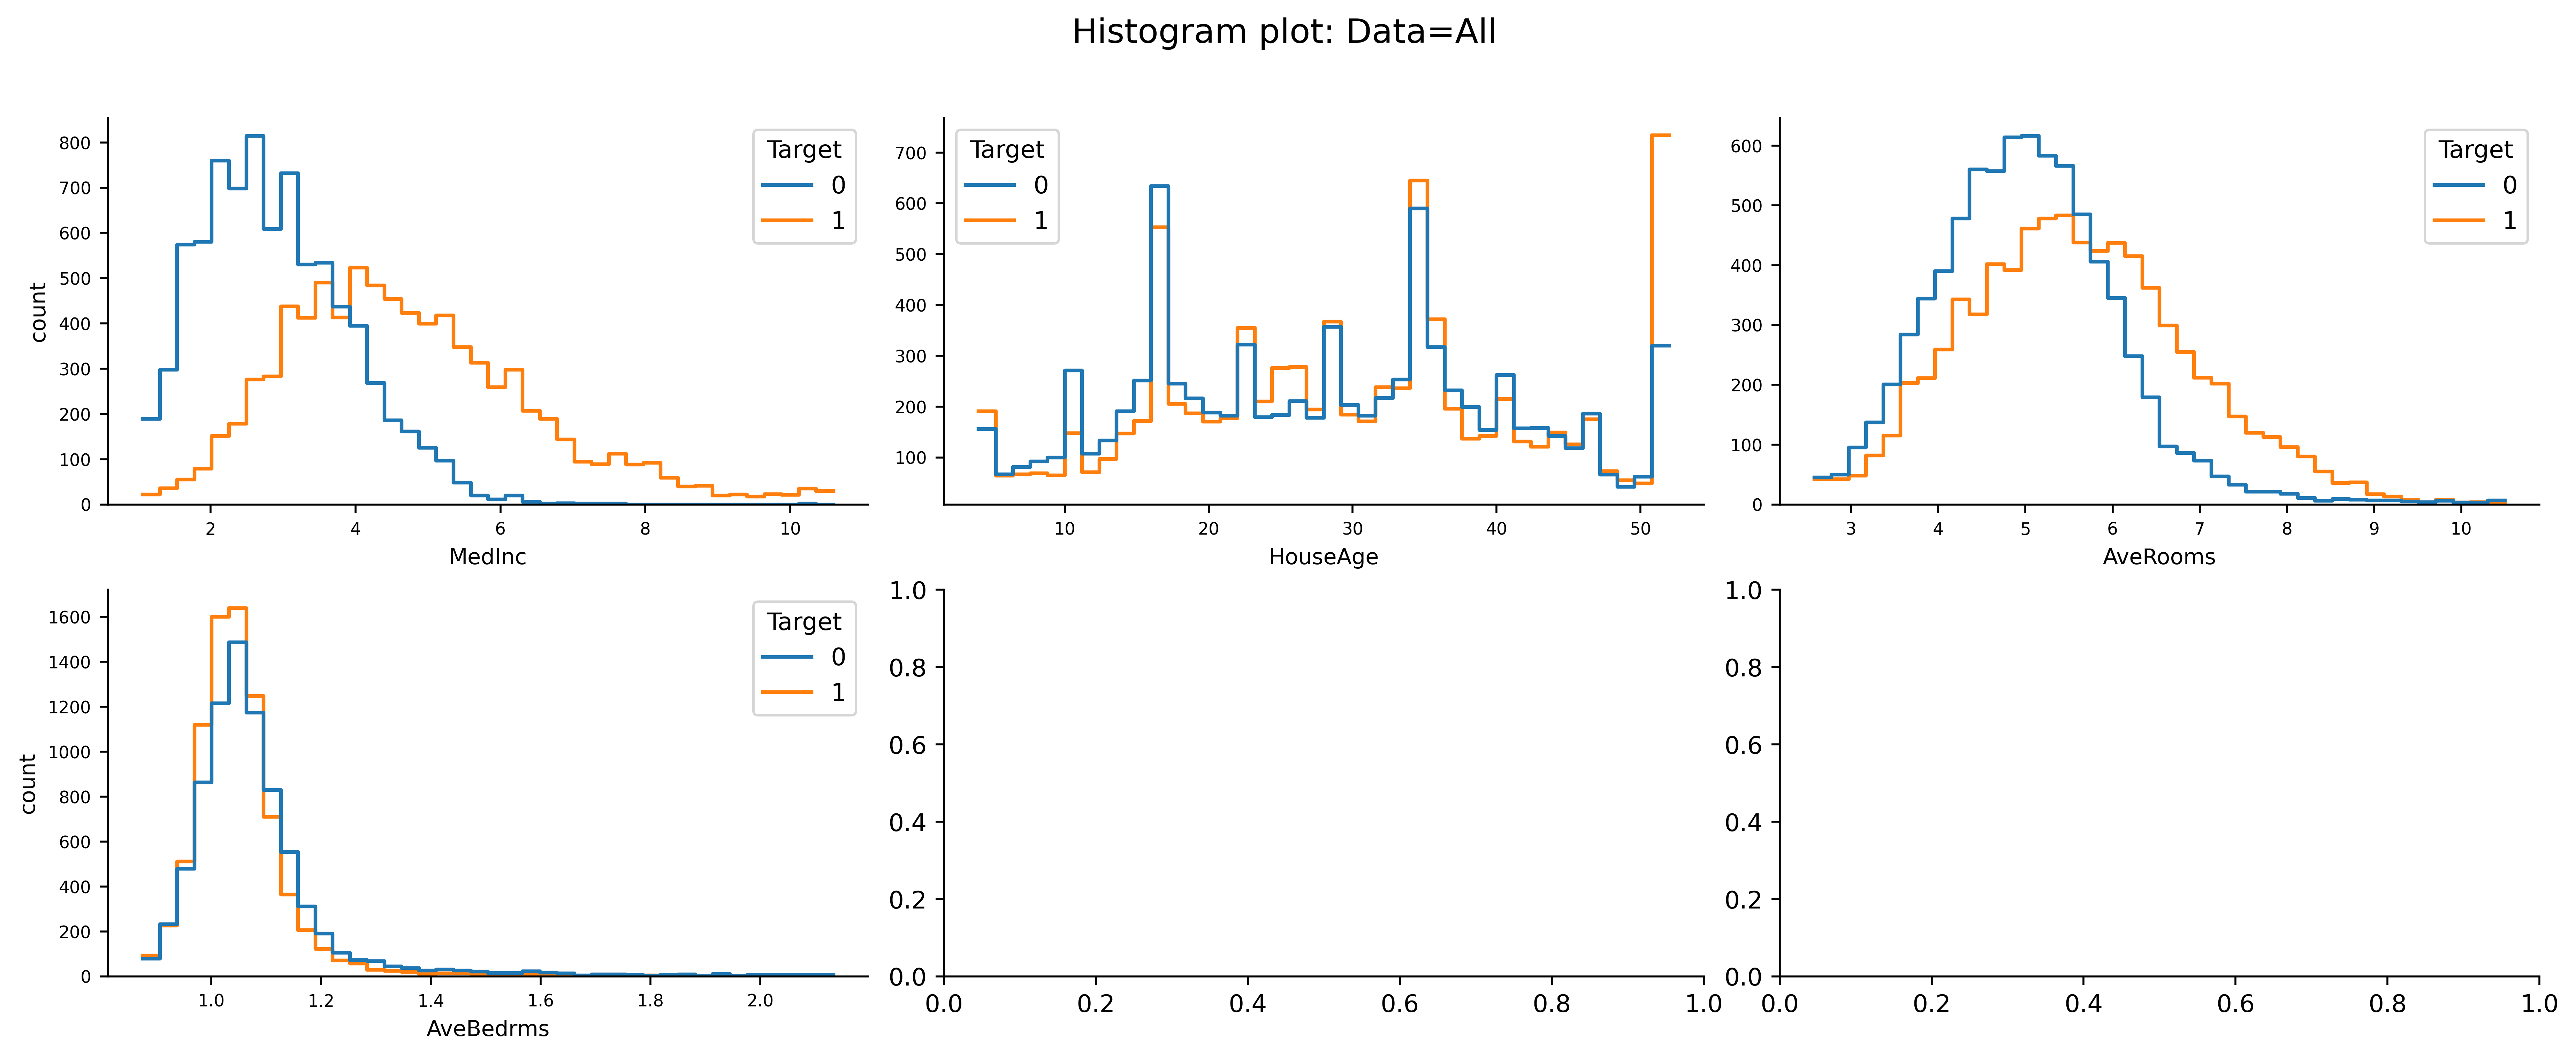

In [10]:
res = DataProfiler_obj.plot_hist(Xy_train, selected_features=feat_names[:4],
                                 hue_col='Target', stat='count', n_cols=3) 

**Example 3**: Plot two sets of data <br>

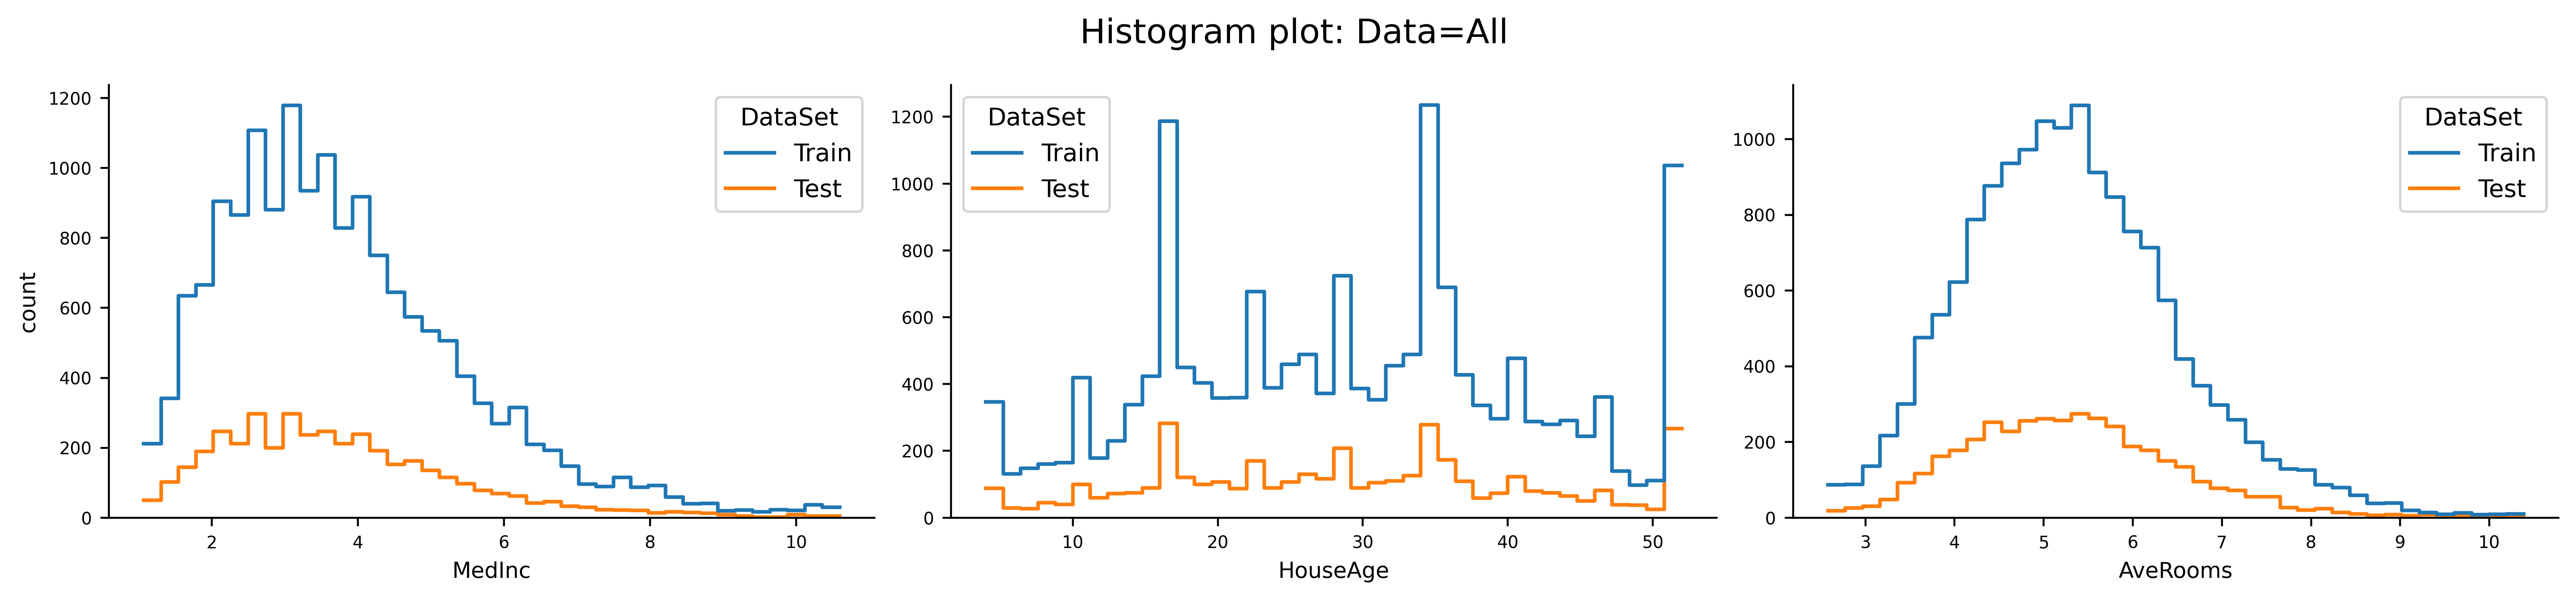

In [11]:
res= DataProfiler_obj.plot_hist(data={'Train':X_train, "Test":X_test}, 
                                selected_features=feat_names[:3], n_cols=3, 
                                stat='count', fill=False, element='step' , save_results=False)

**Example 4**: Two sets of data and also splitted based on `hul_col` <br>
*Important Note*: When there is more than one set of data, they will be concatenated

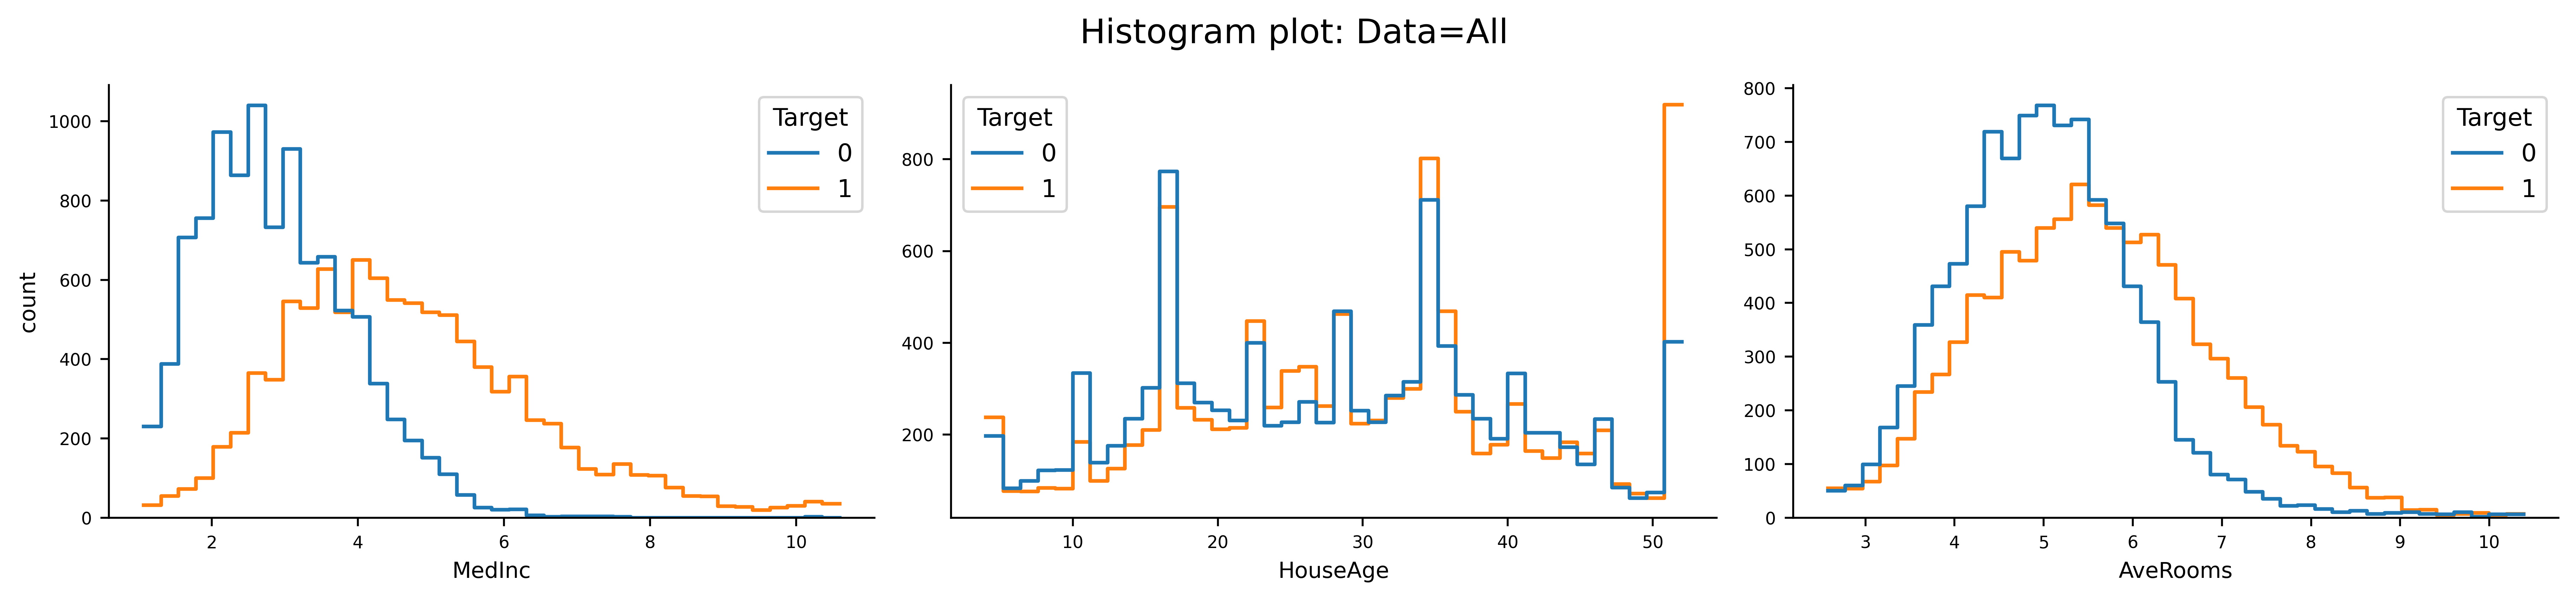

In [12]:
res = DataProfiler_obj.plot_hist(data={'Train':Xy_train,'Test':Xy_test}, 
                                selected_features=feat_names[:3], n_cols=3, stat='count', hue_col='Target', save_results=False)

### 5. Outlier analysis

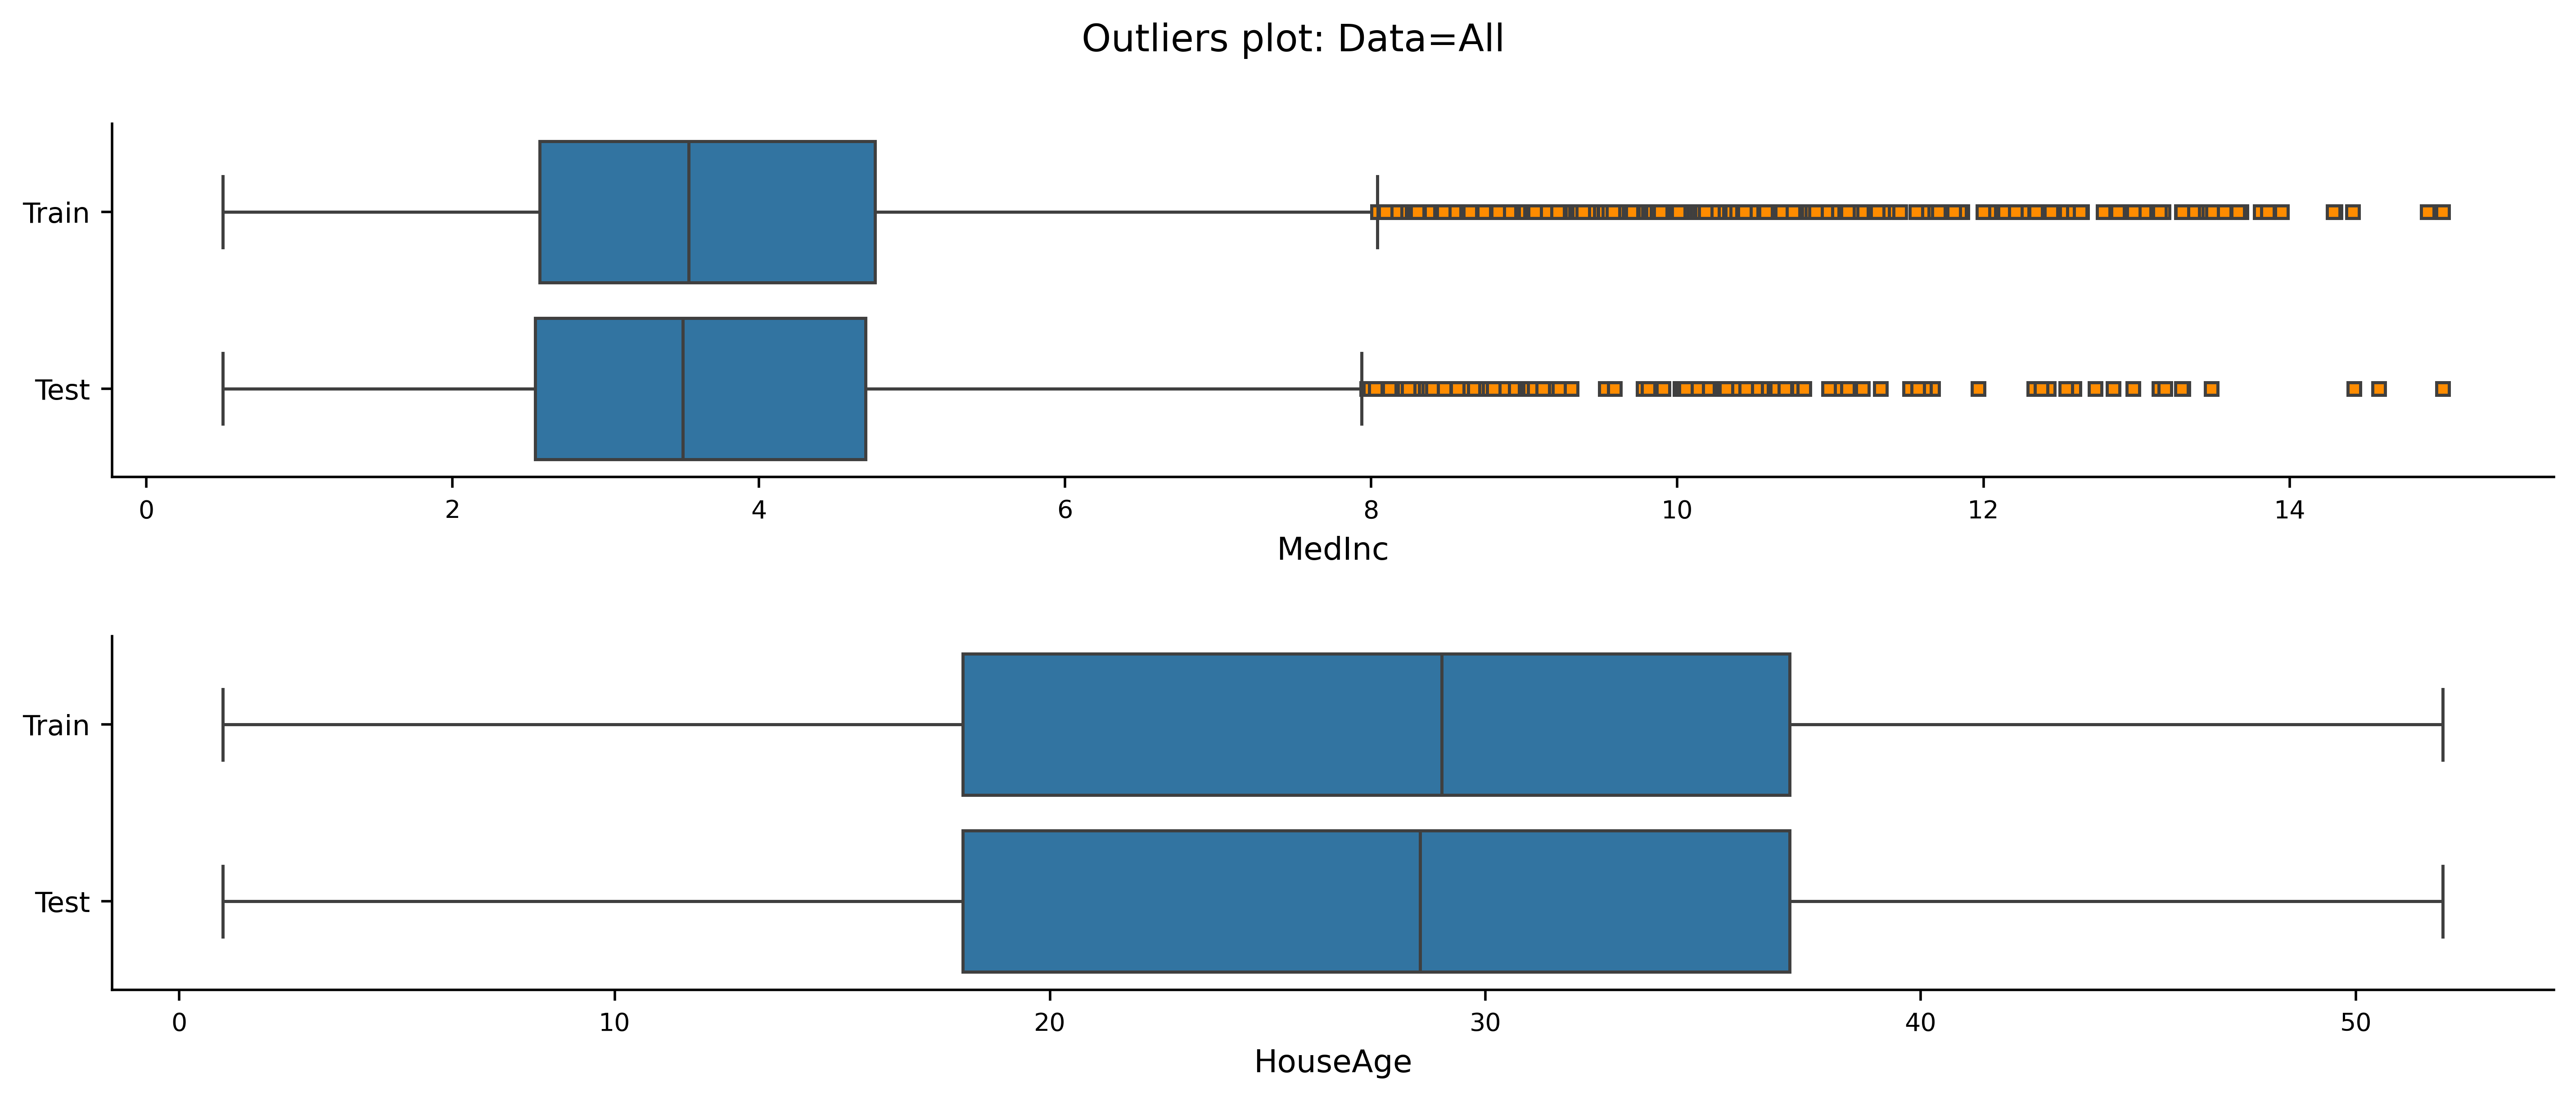

In [13]:
res = DataProfiler_obj.plot_outliers(data={'Train':Xy_train,'Test':Xy_test}, 
                                     selected_features=feat_names[:2])

# DataProfiling in different Segments

### Create the Object

In [14]:
from DataProfiler import DataProfiler
DataProfiler_obj = DataProfiler()

### General desciptions of features 

<div class="alert alert-block alert-info">
    <b> Parameters </b>  
    <ul>
        <li><i>data: </i> DataFrame object or dict: a single dataframe object or a dictionary of some dataframes which will be concatenated. e.x. {'Train':Xy_train,'Test':Xy_test} </li>
        <li><i>joined_col_name: str, optional: </i> if input data is dict, then this is the name of the new column added to the concatenated dataframes in the data. (default is "DataSet"); this column would contain the names of the dataframes existing in the data. e.x. 'Train' label or 'Test' label</li>
        <li><i>selected_features: list, optional</i> list of columns to be analyzed. (default is None, so all columns would get analyzed)</li>
        <li><i>groupby : str or a Pandas Series, optional: </i> the column name or a Pandas Series that the function performs grouping on. (default is None)</li>
        <li><i>bins : list of tuples, optional: </i> the intervals used by the function to cut the groupby column and perform grouping. (default is None); e.x. [(1, 20), (20, 50)]</li>
        <li><i>n_bins: int, optional:  </i> the number of equal-width bins used by the function to cut the groupby column and perform grouping. (default is None)
            (There is no guarantee about the distribution of data in each bin. e.x. a bin may even get empty at the end)</li>
        <li><i> n_quantiles : int, optional: </i> the number of equal-sized (not equal-width) bins used by the function to cut the groupby column and perform grouping. (default is None) (distribution of data in the bins is equal)</li>
        <li><i>save_results : bool, optional: </i> if save_results is True, the function will save the results. (default is True)</li>
    </ul> 
        
</div>    

c:\Users\parsa\Desktop\DataProfiler\Examples\..\DataProfiler.py:273: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gb = groupby_series.groupby(pd.cut(groupby_series, bins=bins))


,DataType,n_uniques (excl. Nulls),n_Missing,Perc. of Missing,n_Zeros,Perc. of Zeros,1st Most Freq,Perc. of 1st Most Freq,Min,1%,50%,99%,Max
MedInc,float64,7886,0,0.0,0,0.0,1.5,10.0,0.5,1,3,11,15
HouseAge,int64,32,0,0.0,0,0.0,36.0,30.0,21.0,21,35,52,52
AveRooms,float64,10372,622,5.4,0,0.0,3.8,10.0,0.8,3,5,9,142
AveBedrms,float64,8536,10,0.1,0,0.0,nan,30.0,0.3,1,1,2,34
Population,float64,2871,9,0.1,0,0.0,nan,70.0,5.0,96,"1,093","4,108","9,879"
AveOccup,float64,10751,0,0.0,0,0.0,3.9,10.0,1.1,2,3,5,"1,243"
Latitude,float64,720,0,0.0,0,0.0,33.9,20.0,32.6,33,34,41,42
Longitude,float64,716,0,0.0,0,0.0,-118.3,10.0,-124.3,-123,-118,-117,-115
Target,int64,2,0,0.0,5472,47.7,1.0,60.0,0.0,0,1,1,1


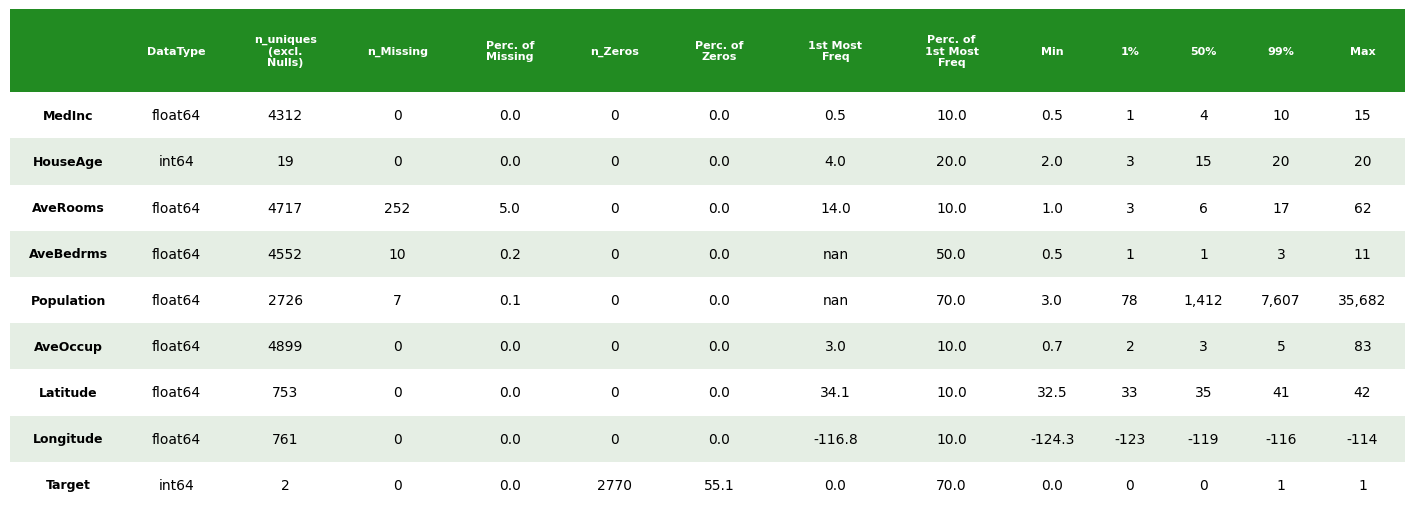

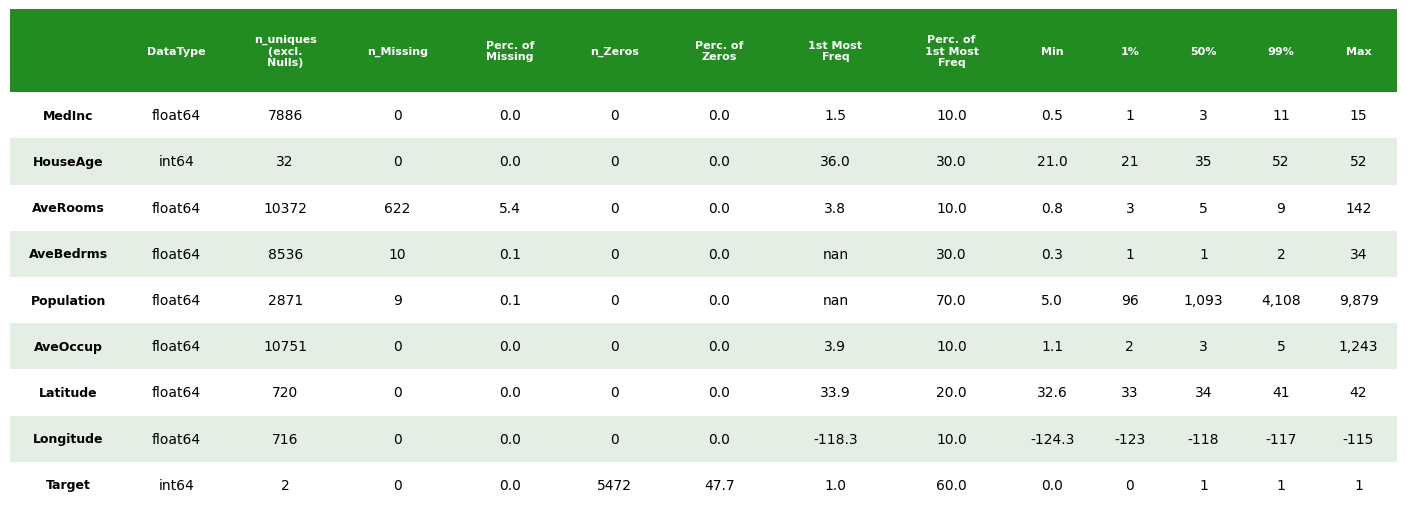

In [15]:
DataProfiler_obj.describe_data(Xy_train, groupby=Xy_train['HouseAge'], bins=[(1, 20), (20, 55)], save_results=True)

### Missing Value Anlaysis

In [16]:
DataProfiler_obj.missing_analysis(Xy_train, groupby='HouseAge', n_quantiles=2, save_results=False)



c:\Users\parsa\Desktop\DataProfiler\Examples\..\DataProfiler.py:277: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gb = groupby_series.groupby(pd.qcut(groupby_series, q=n_quantiles))


,number_of_missing,percentage_of_missing
AveRooms,428,5.34
AveBedrms,8,0.10
Population,8,0.10


### Correlation Analysis

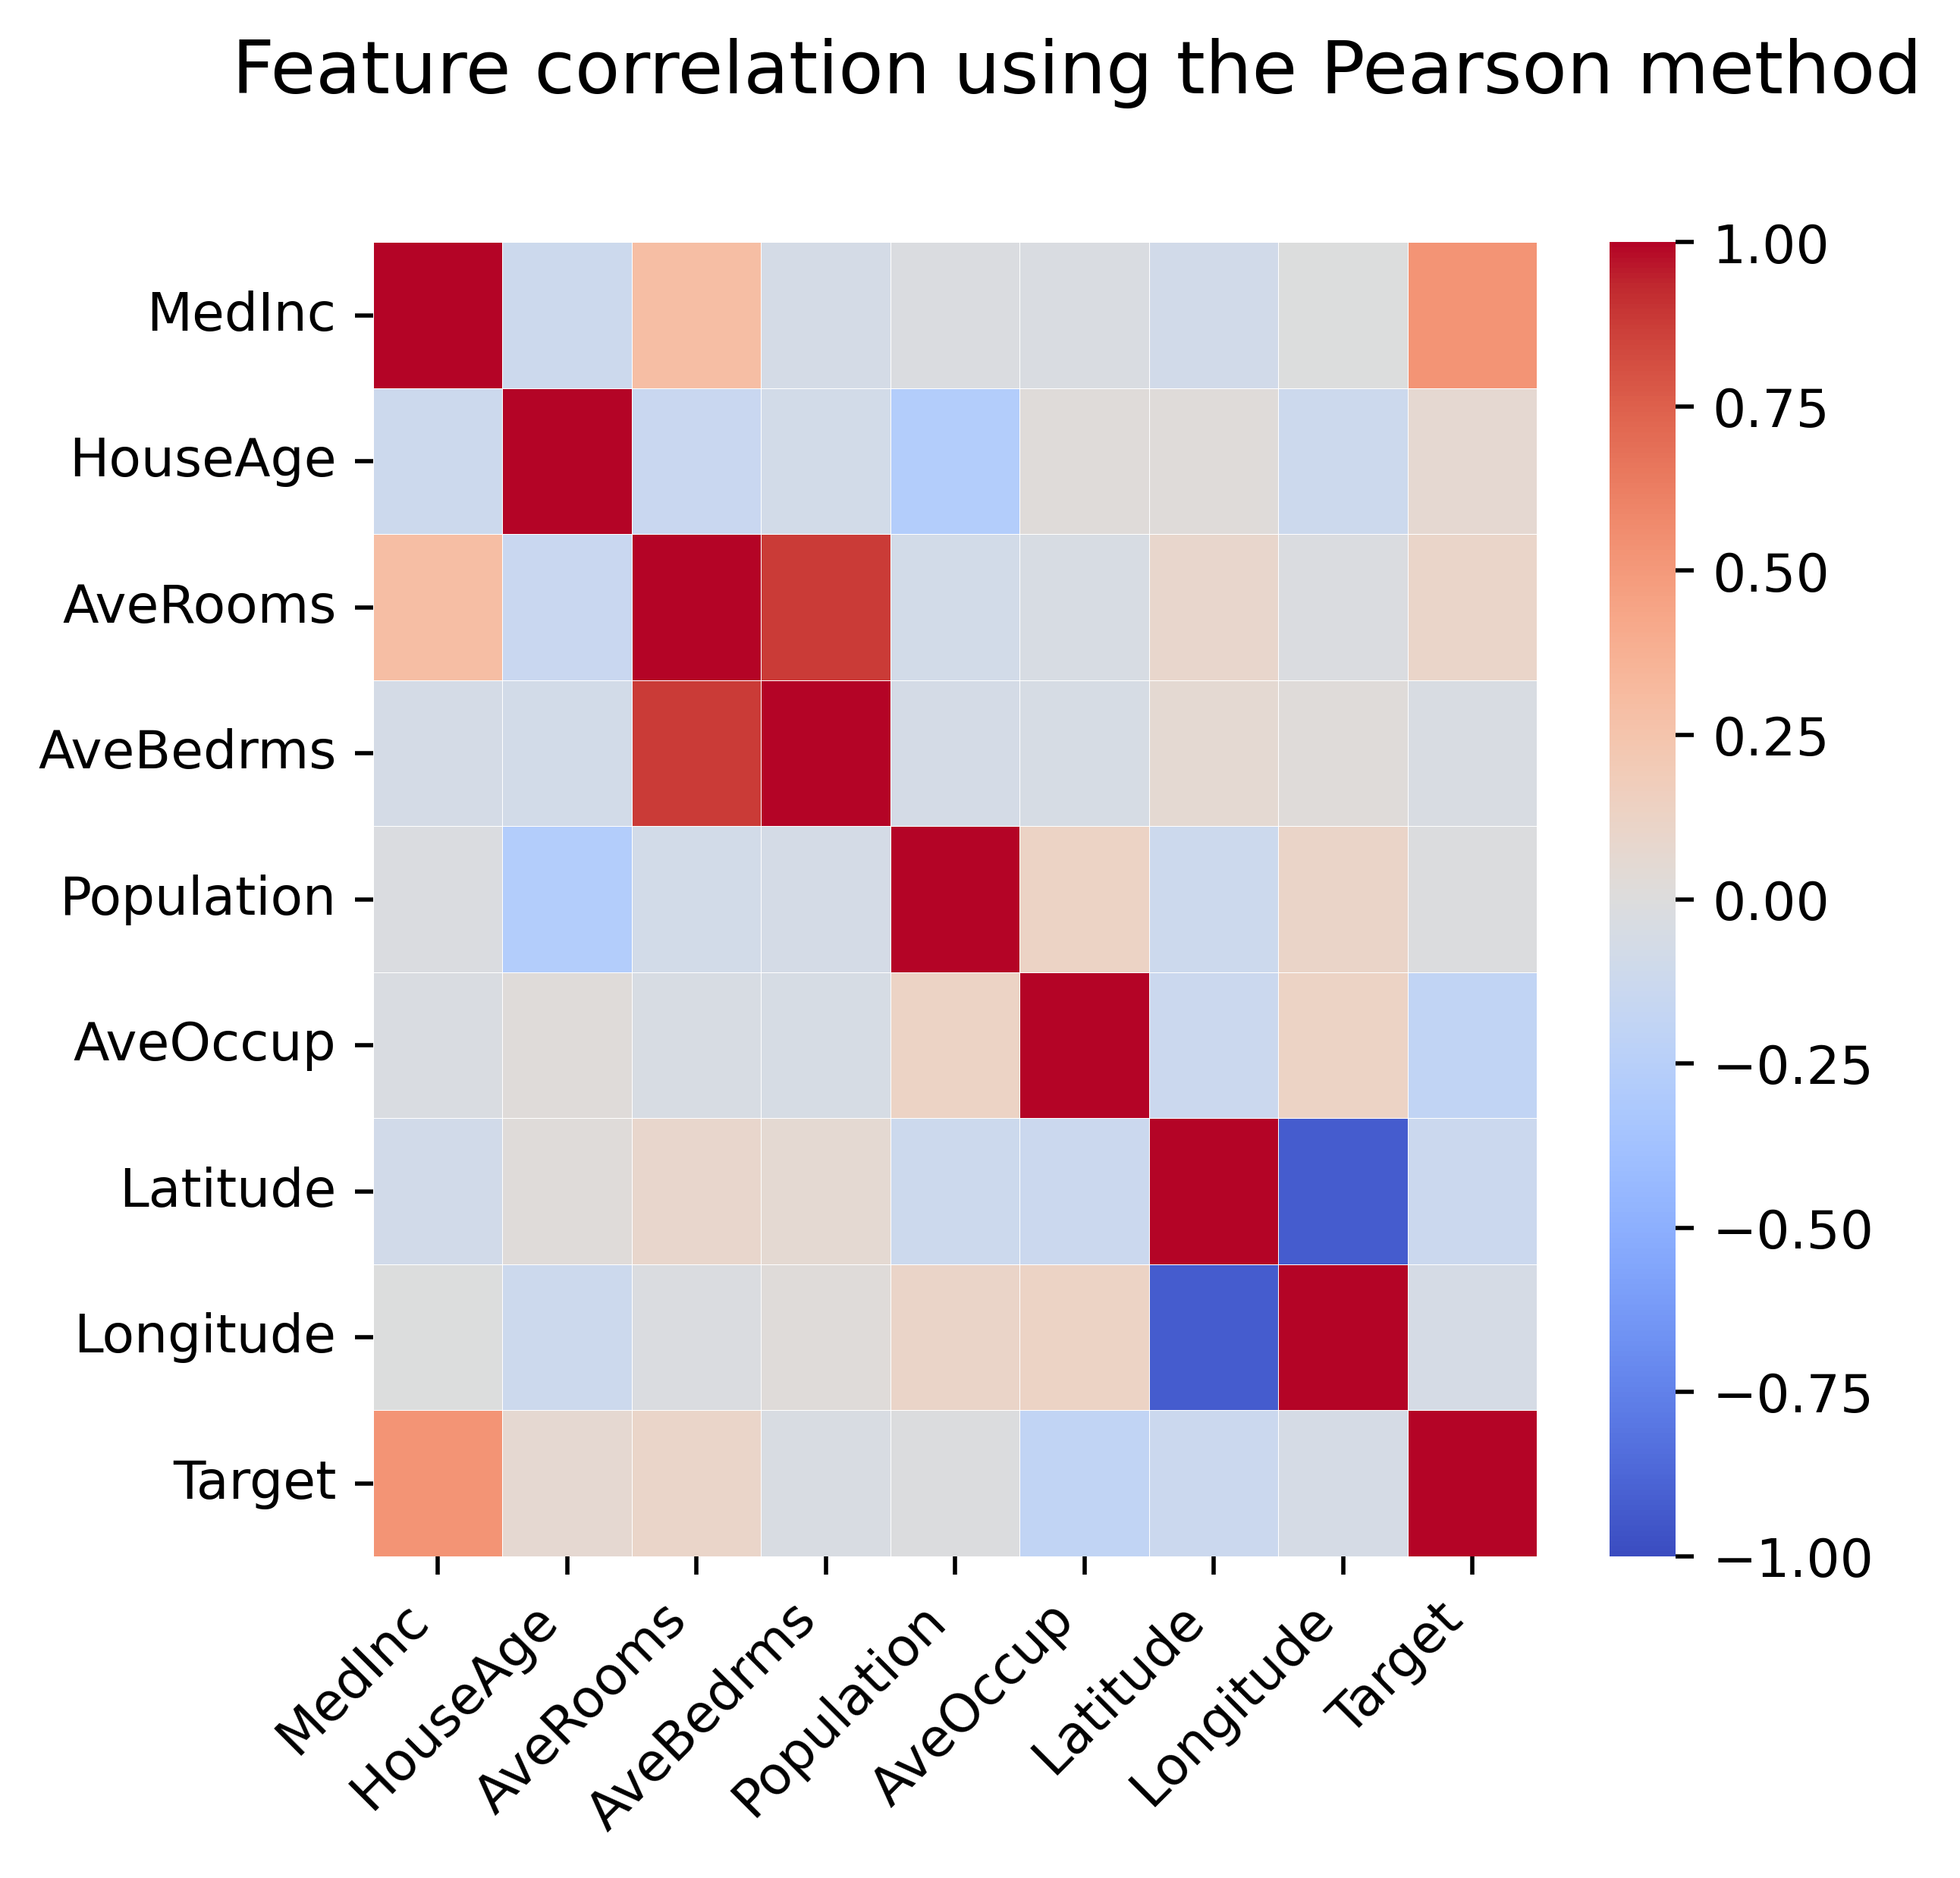

corr_vals without Nulls.shape (9, 9)


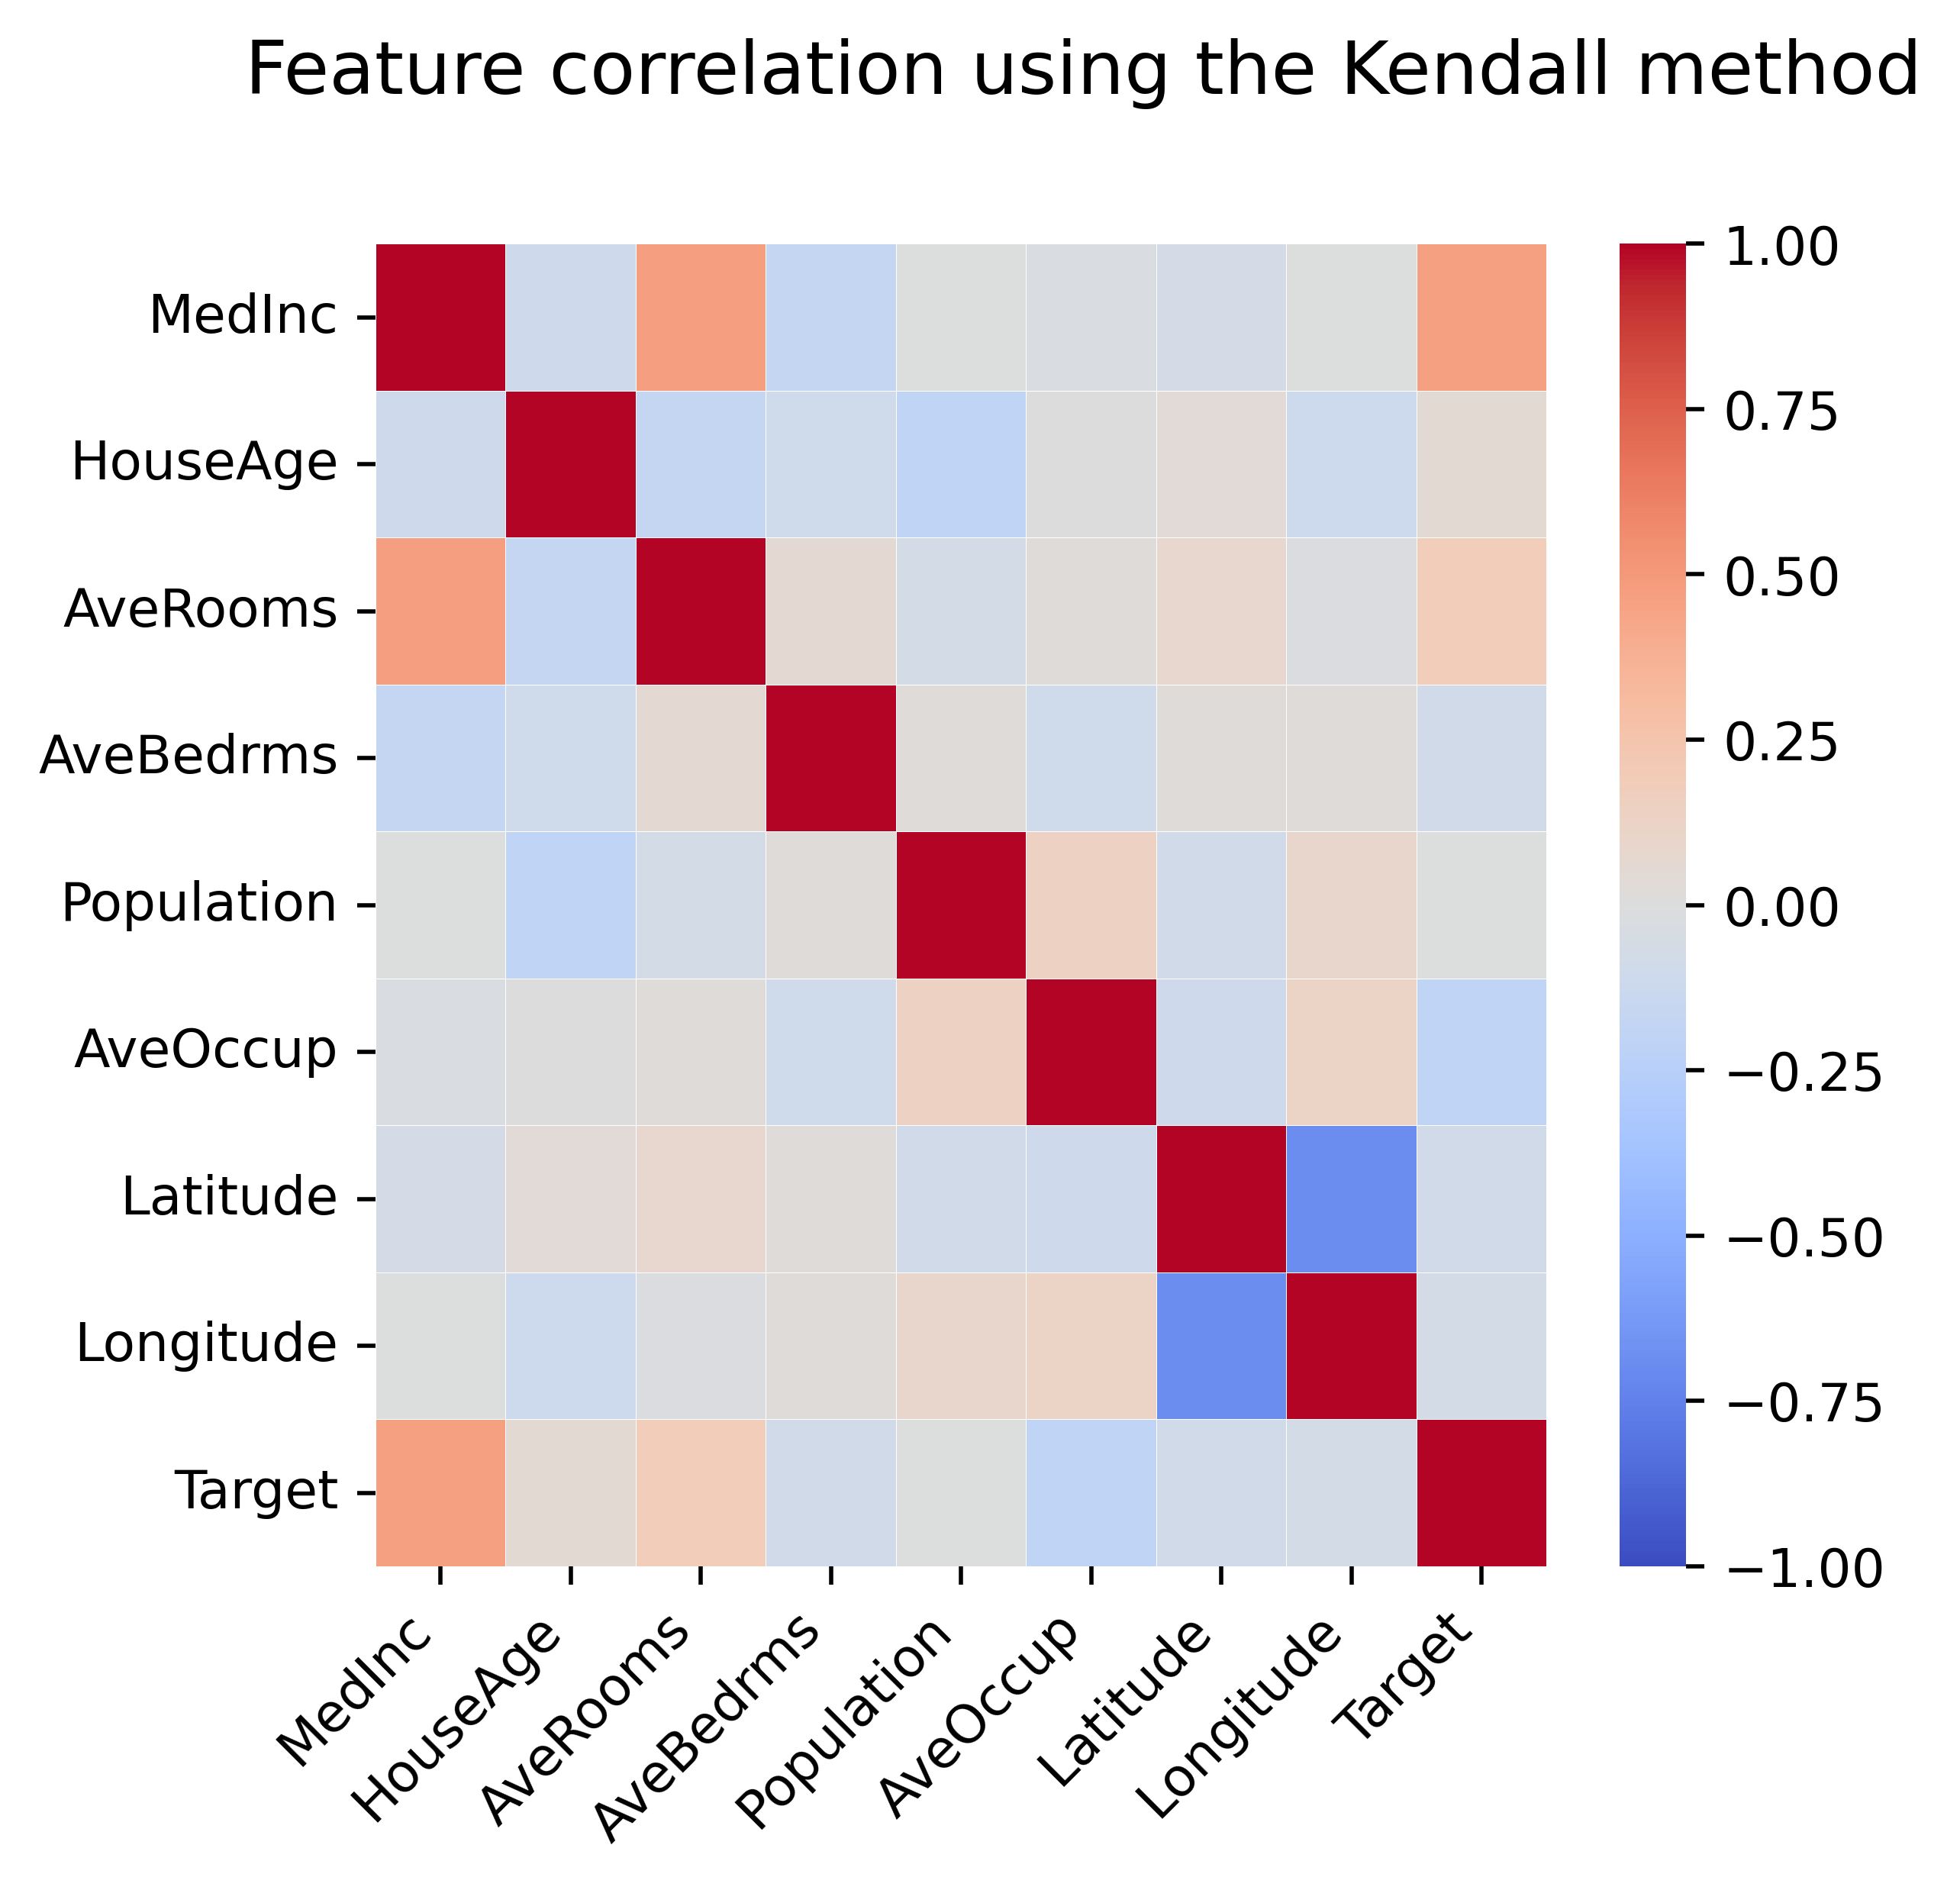

corr_vals without Nulls.shape (9, 9)


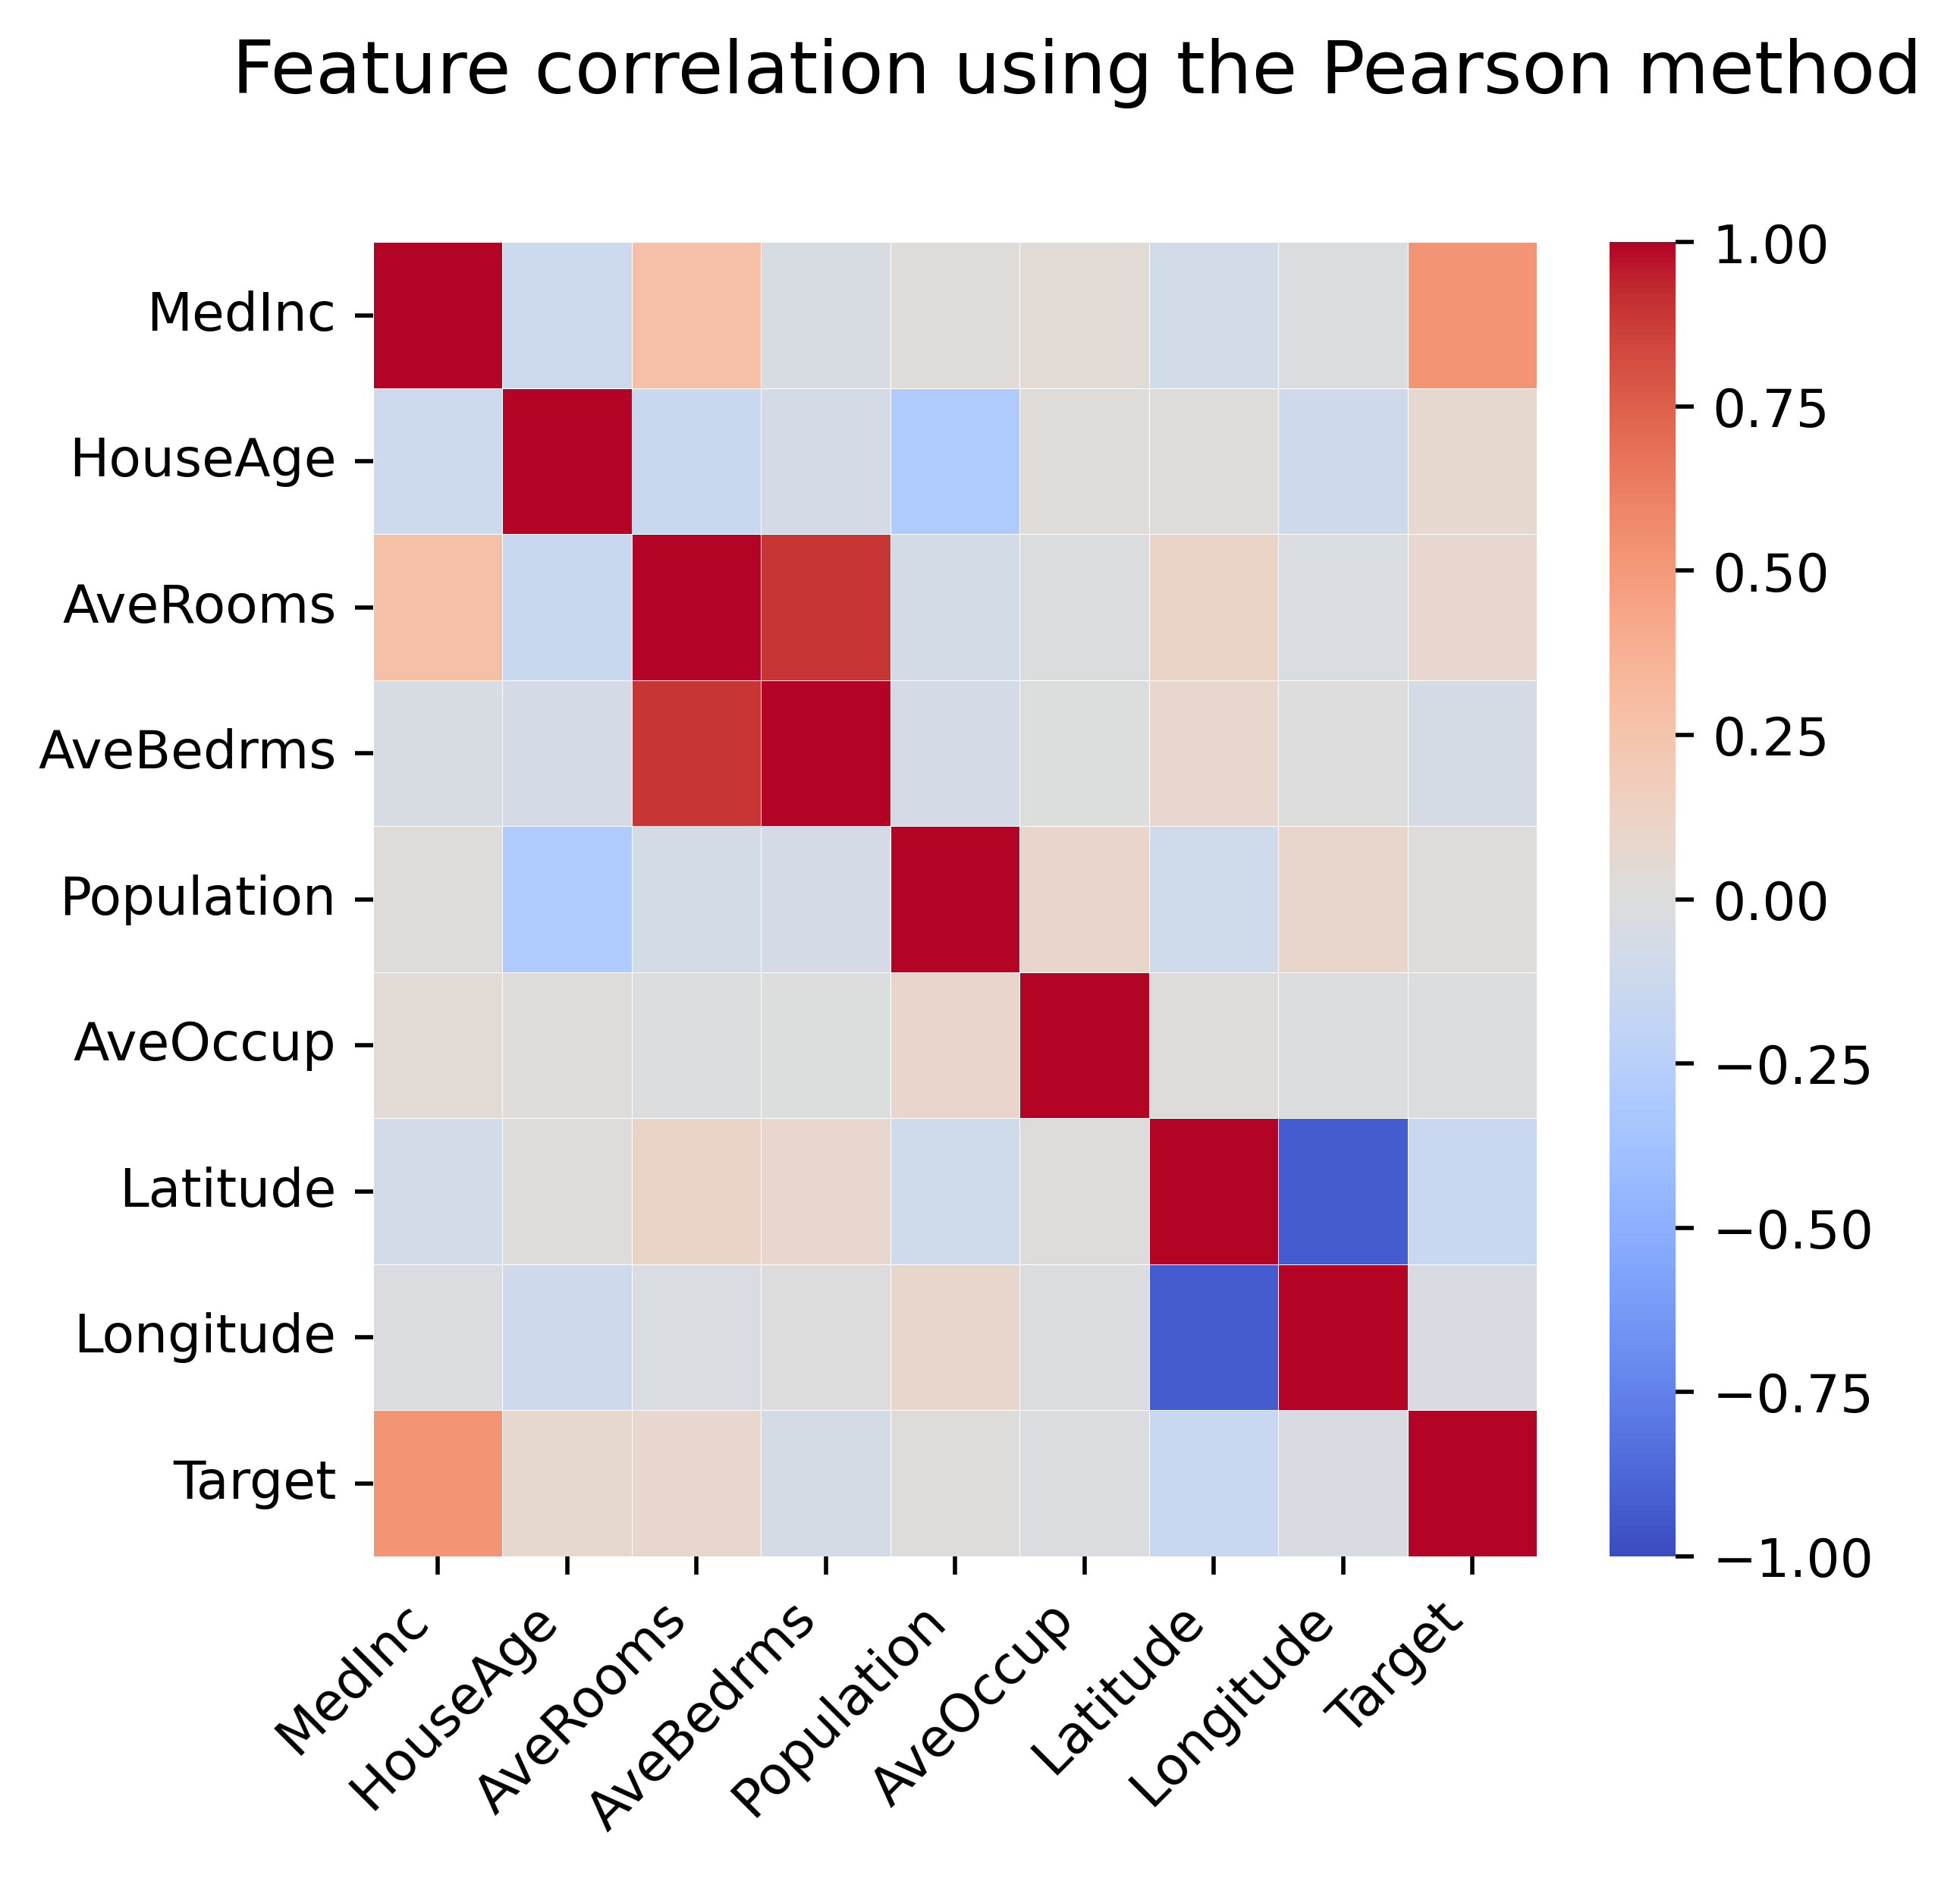

corr_vals without Nulls.shape (9, 9)


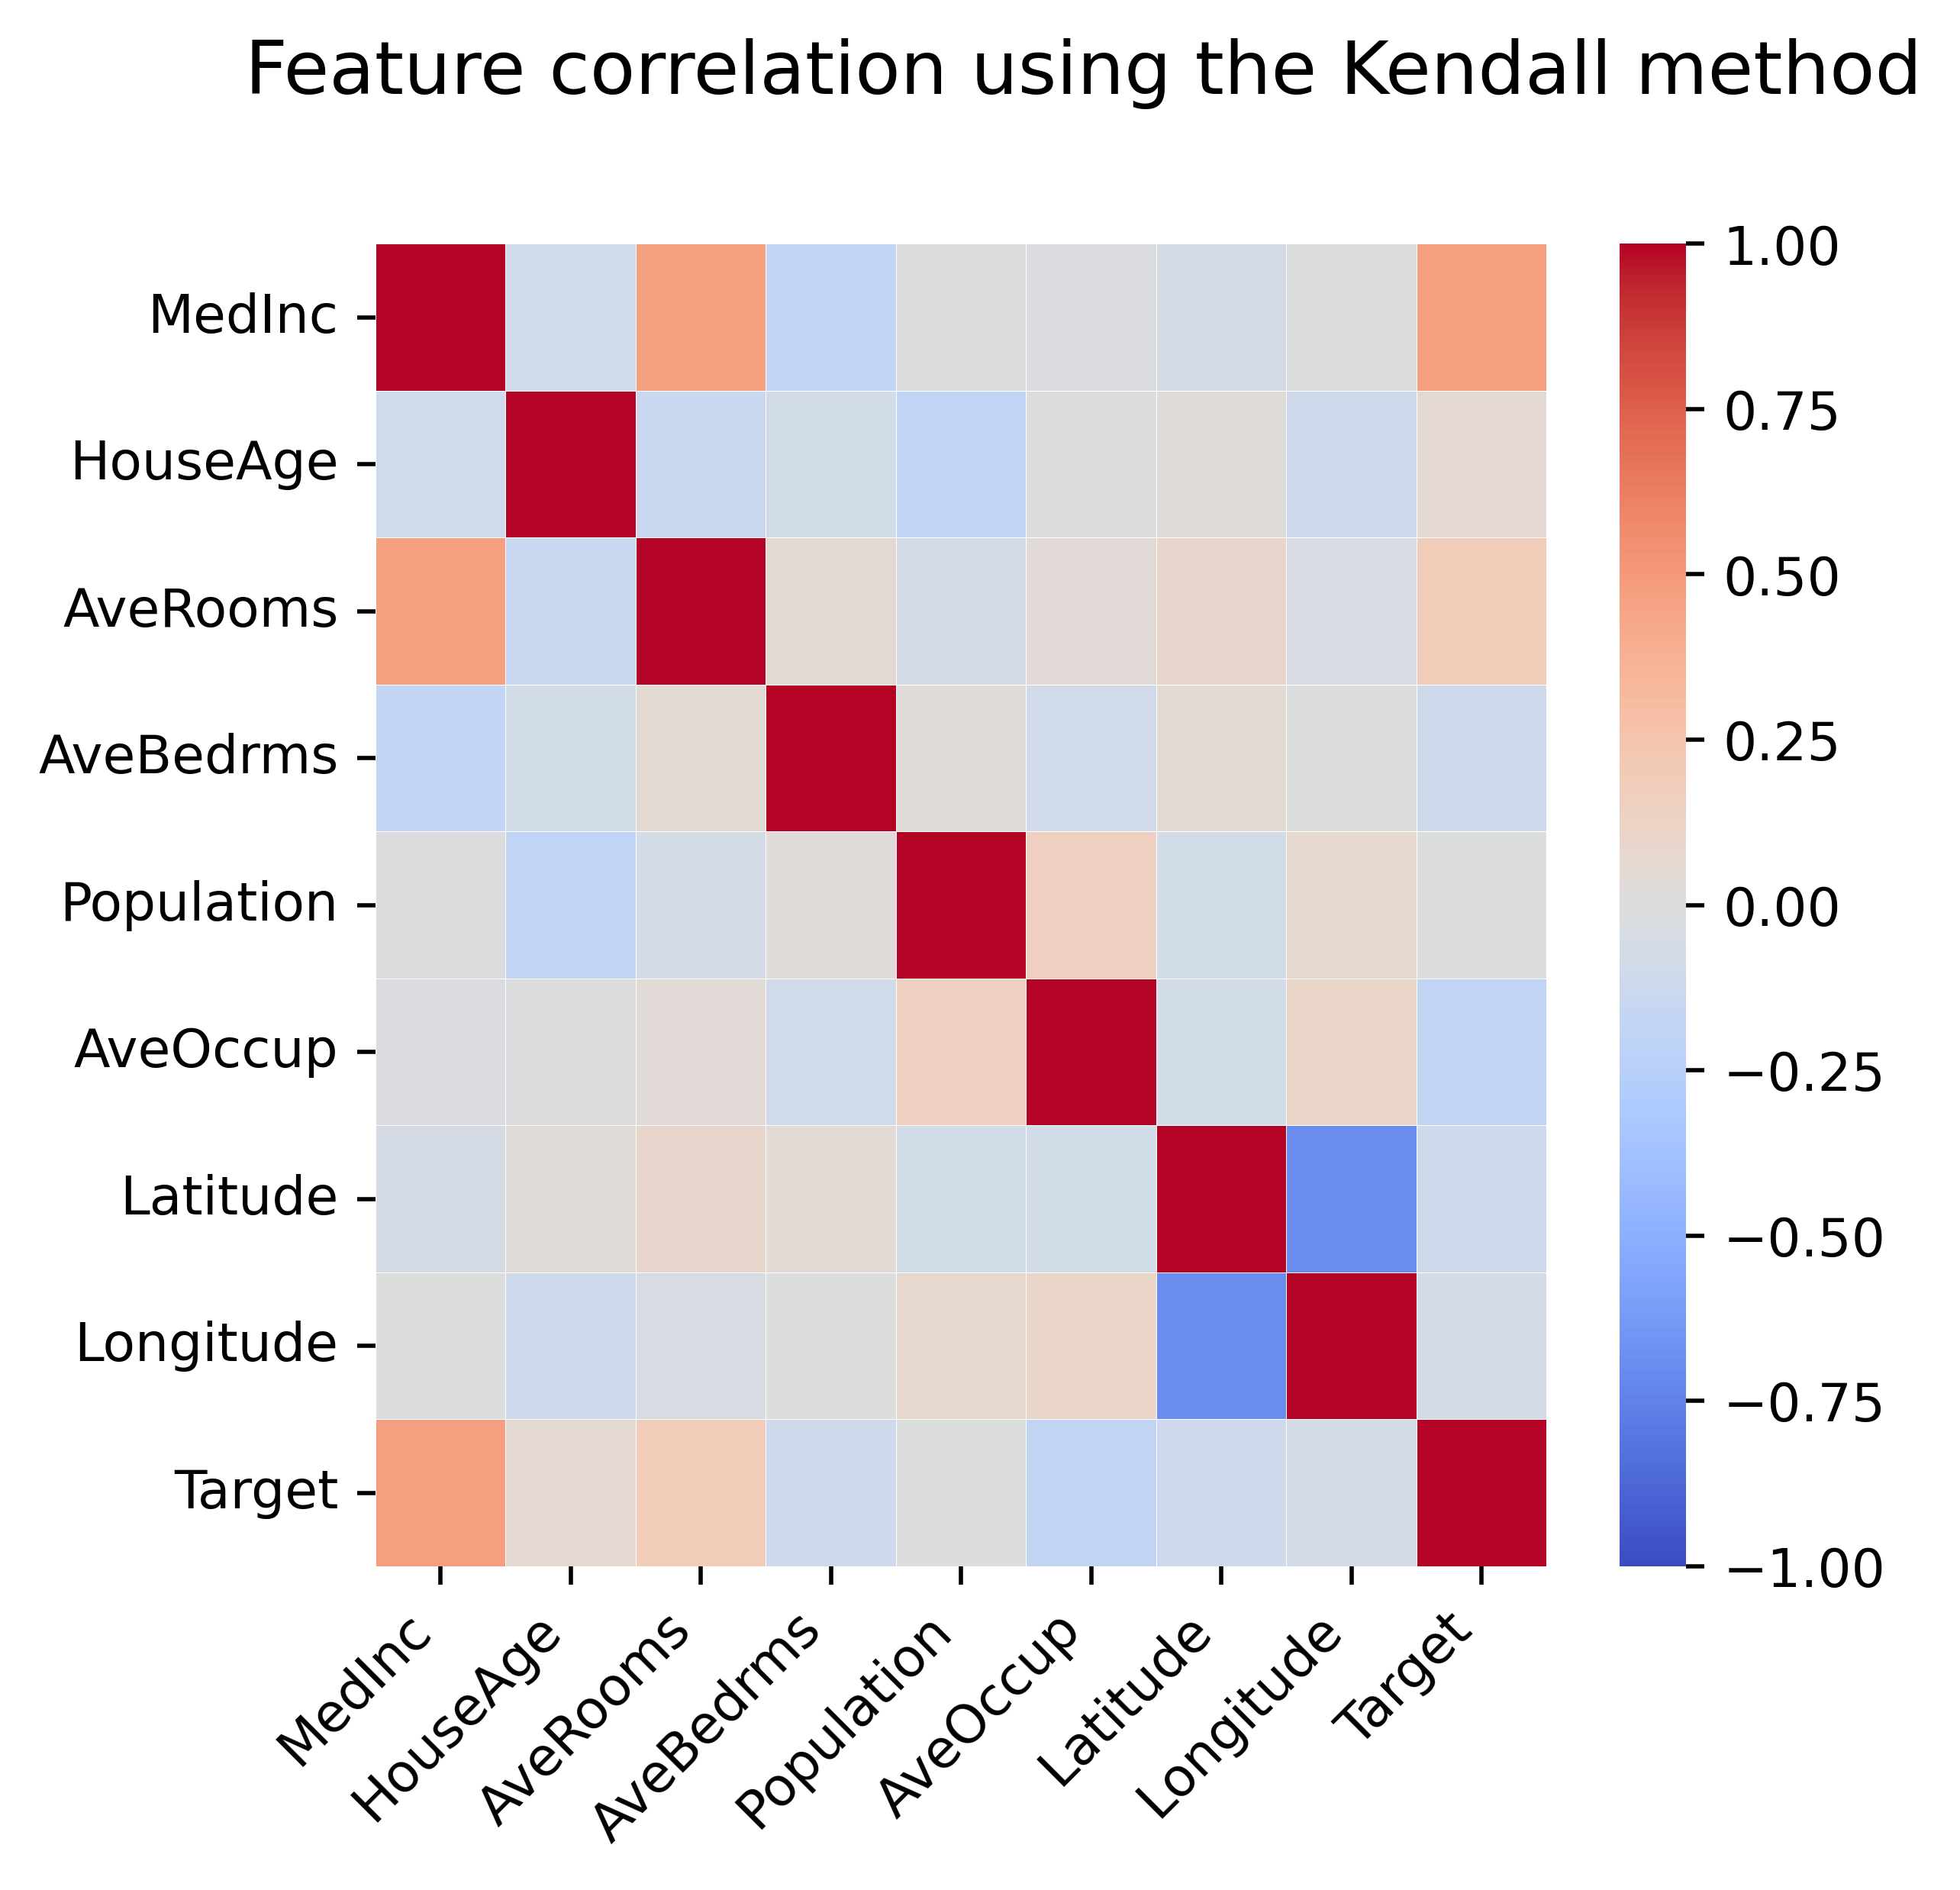

corr_vals without Nulls.shape (9, 9)


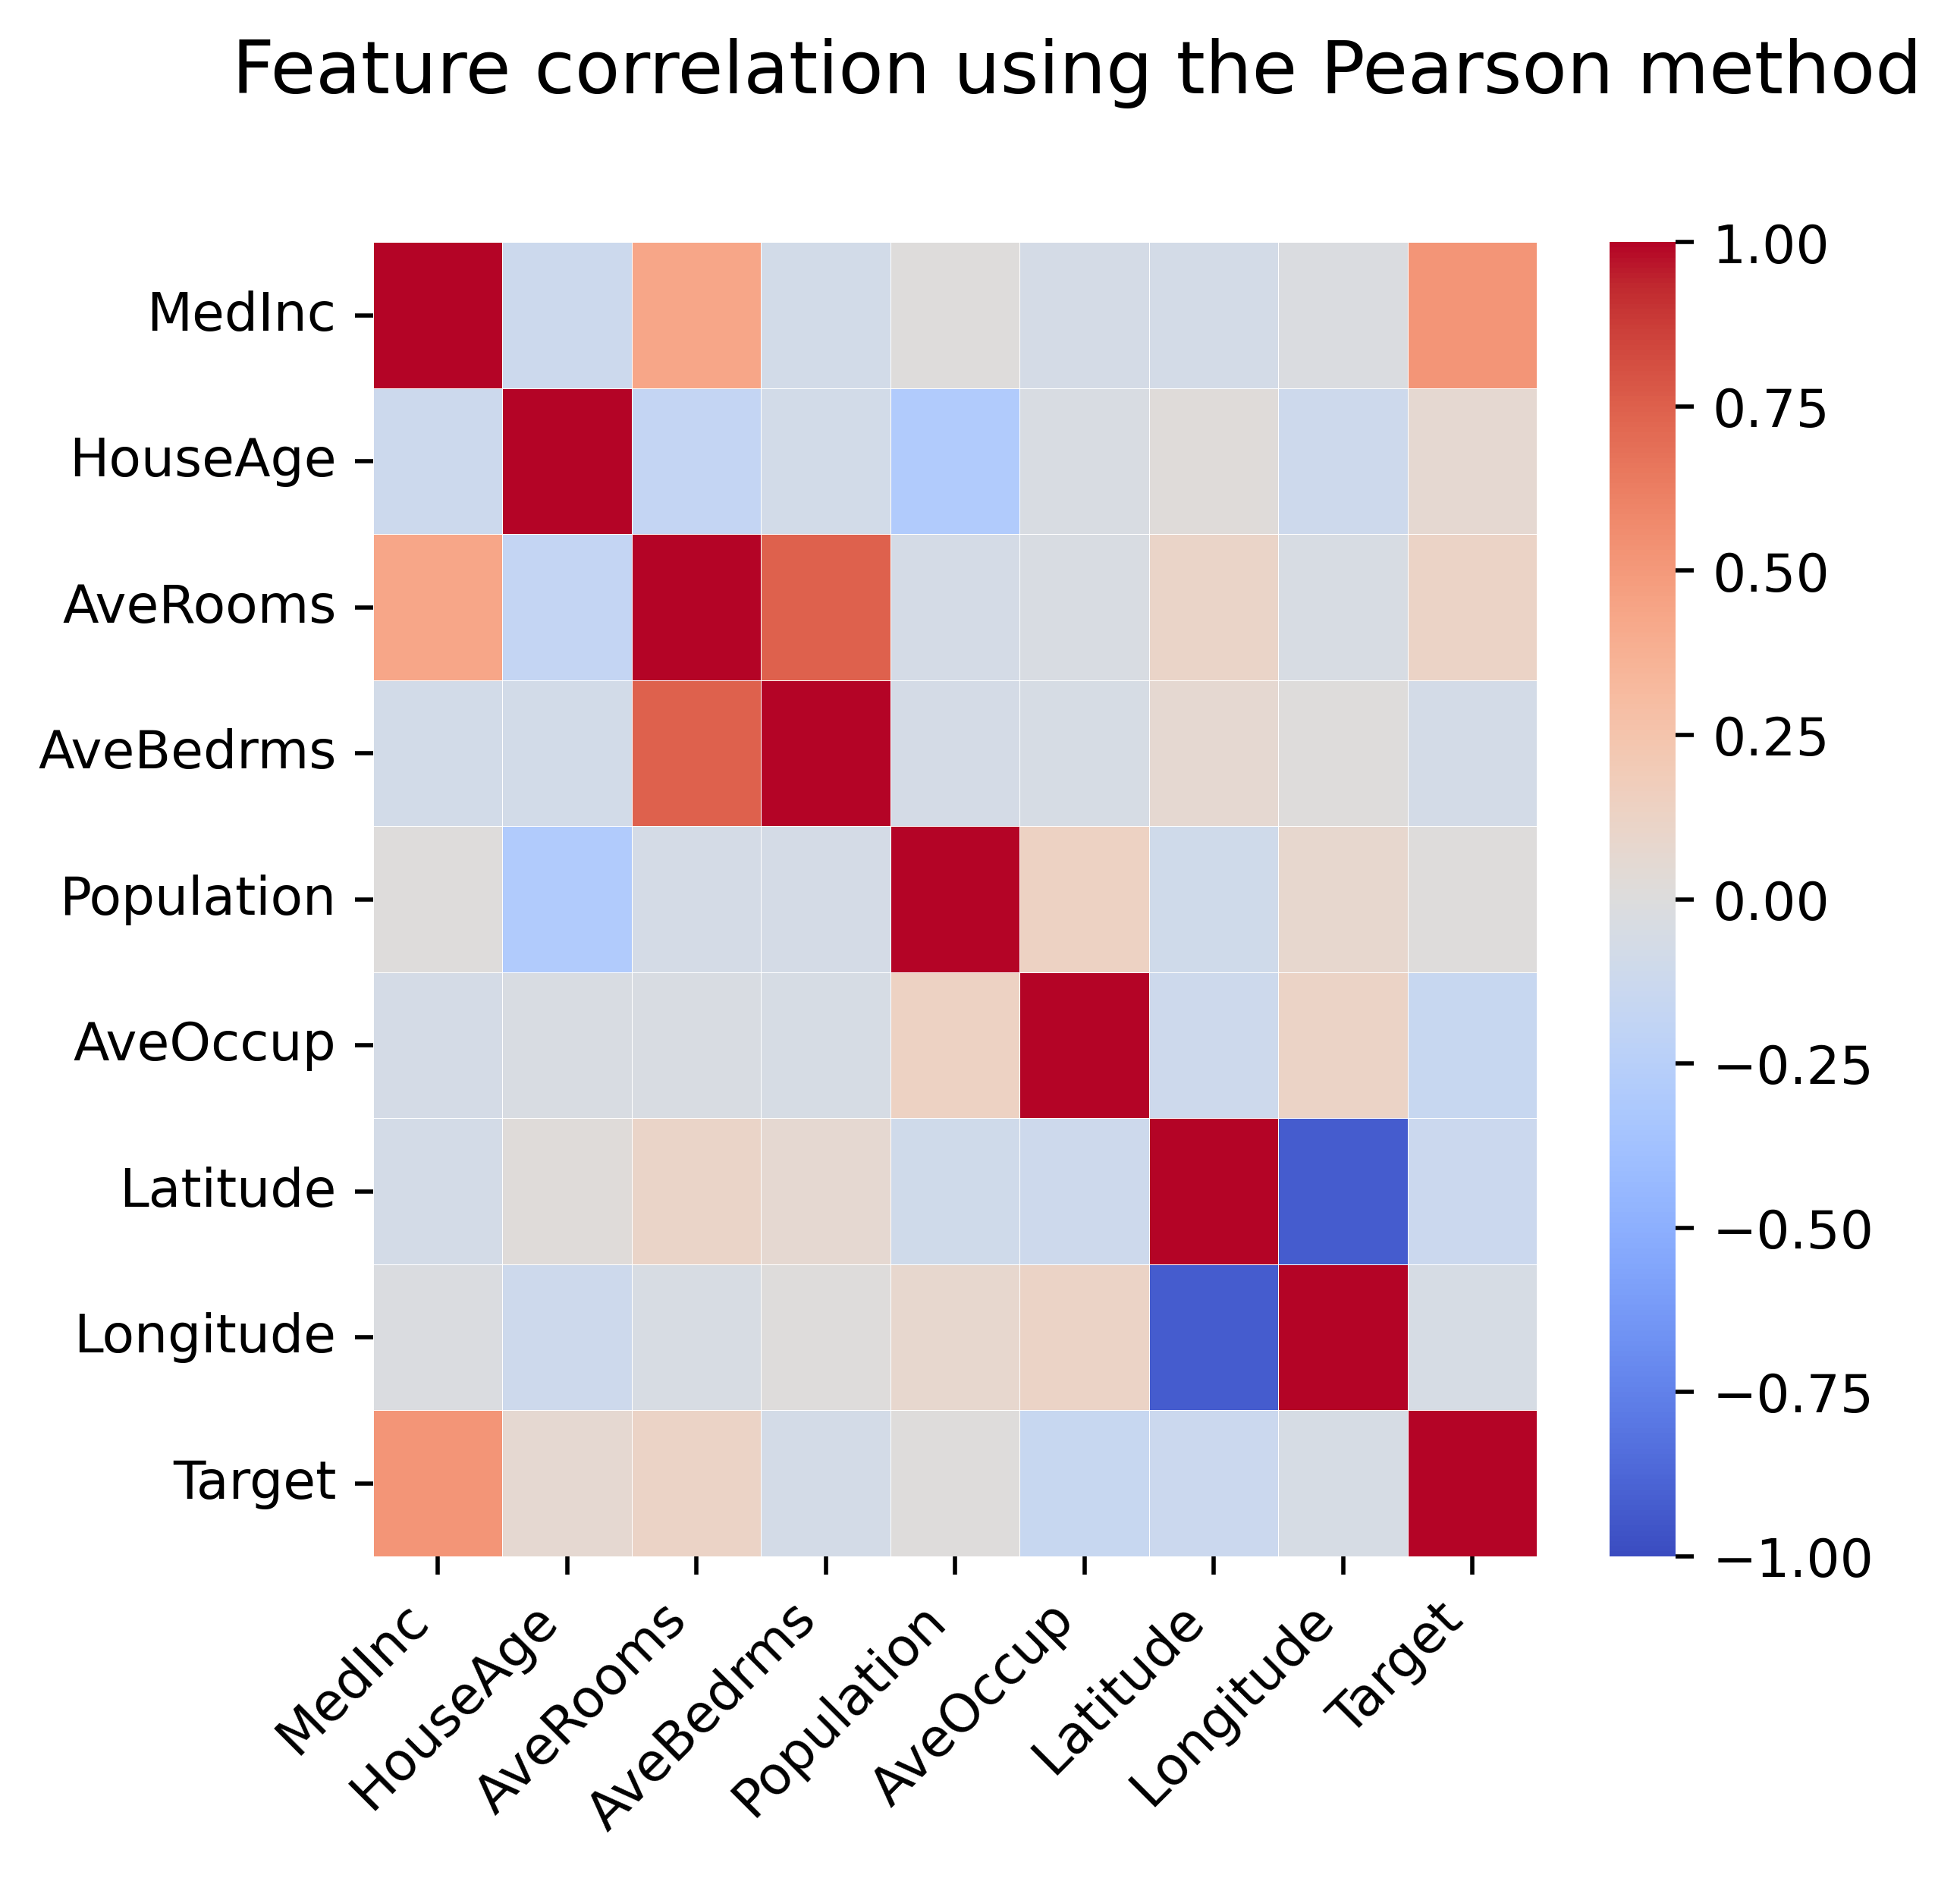

corr_vals without Nulls.shape (9, 9)


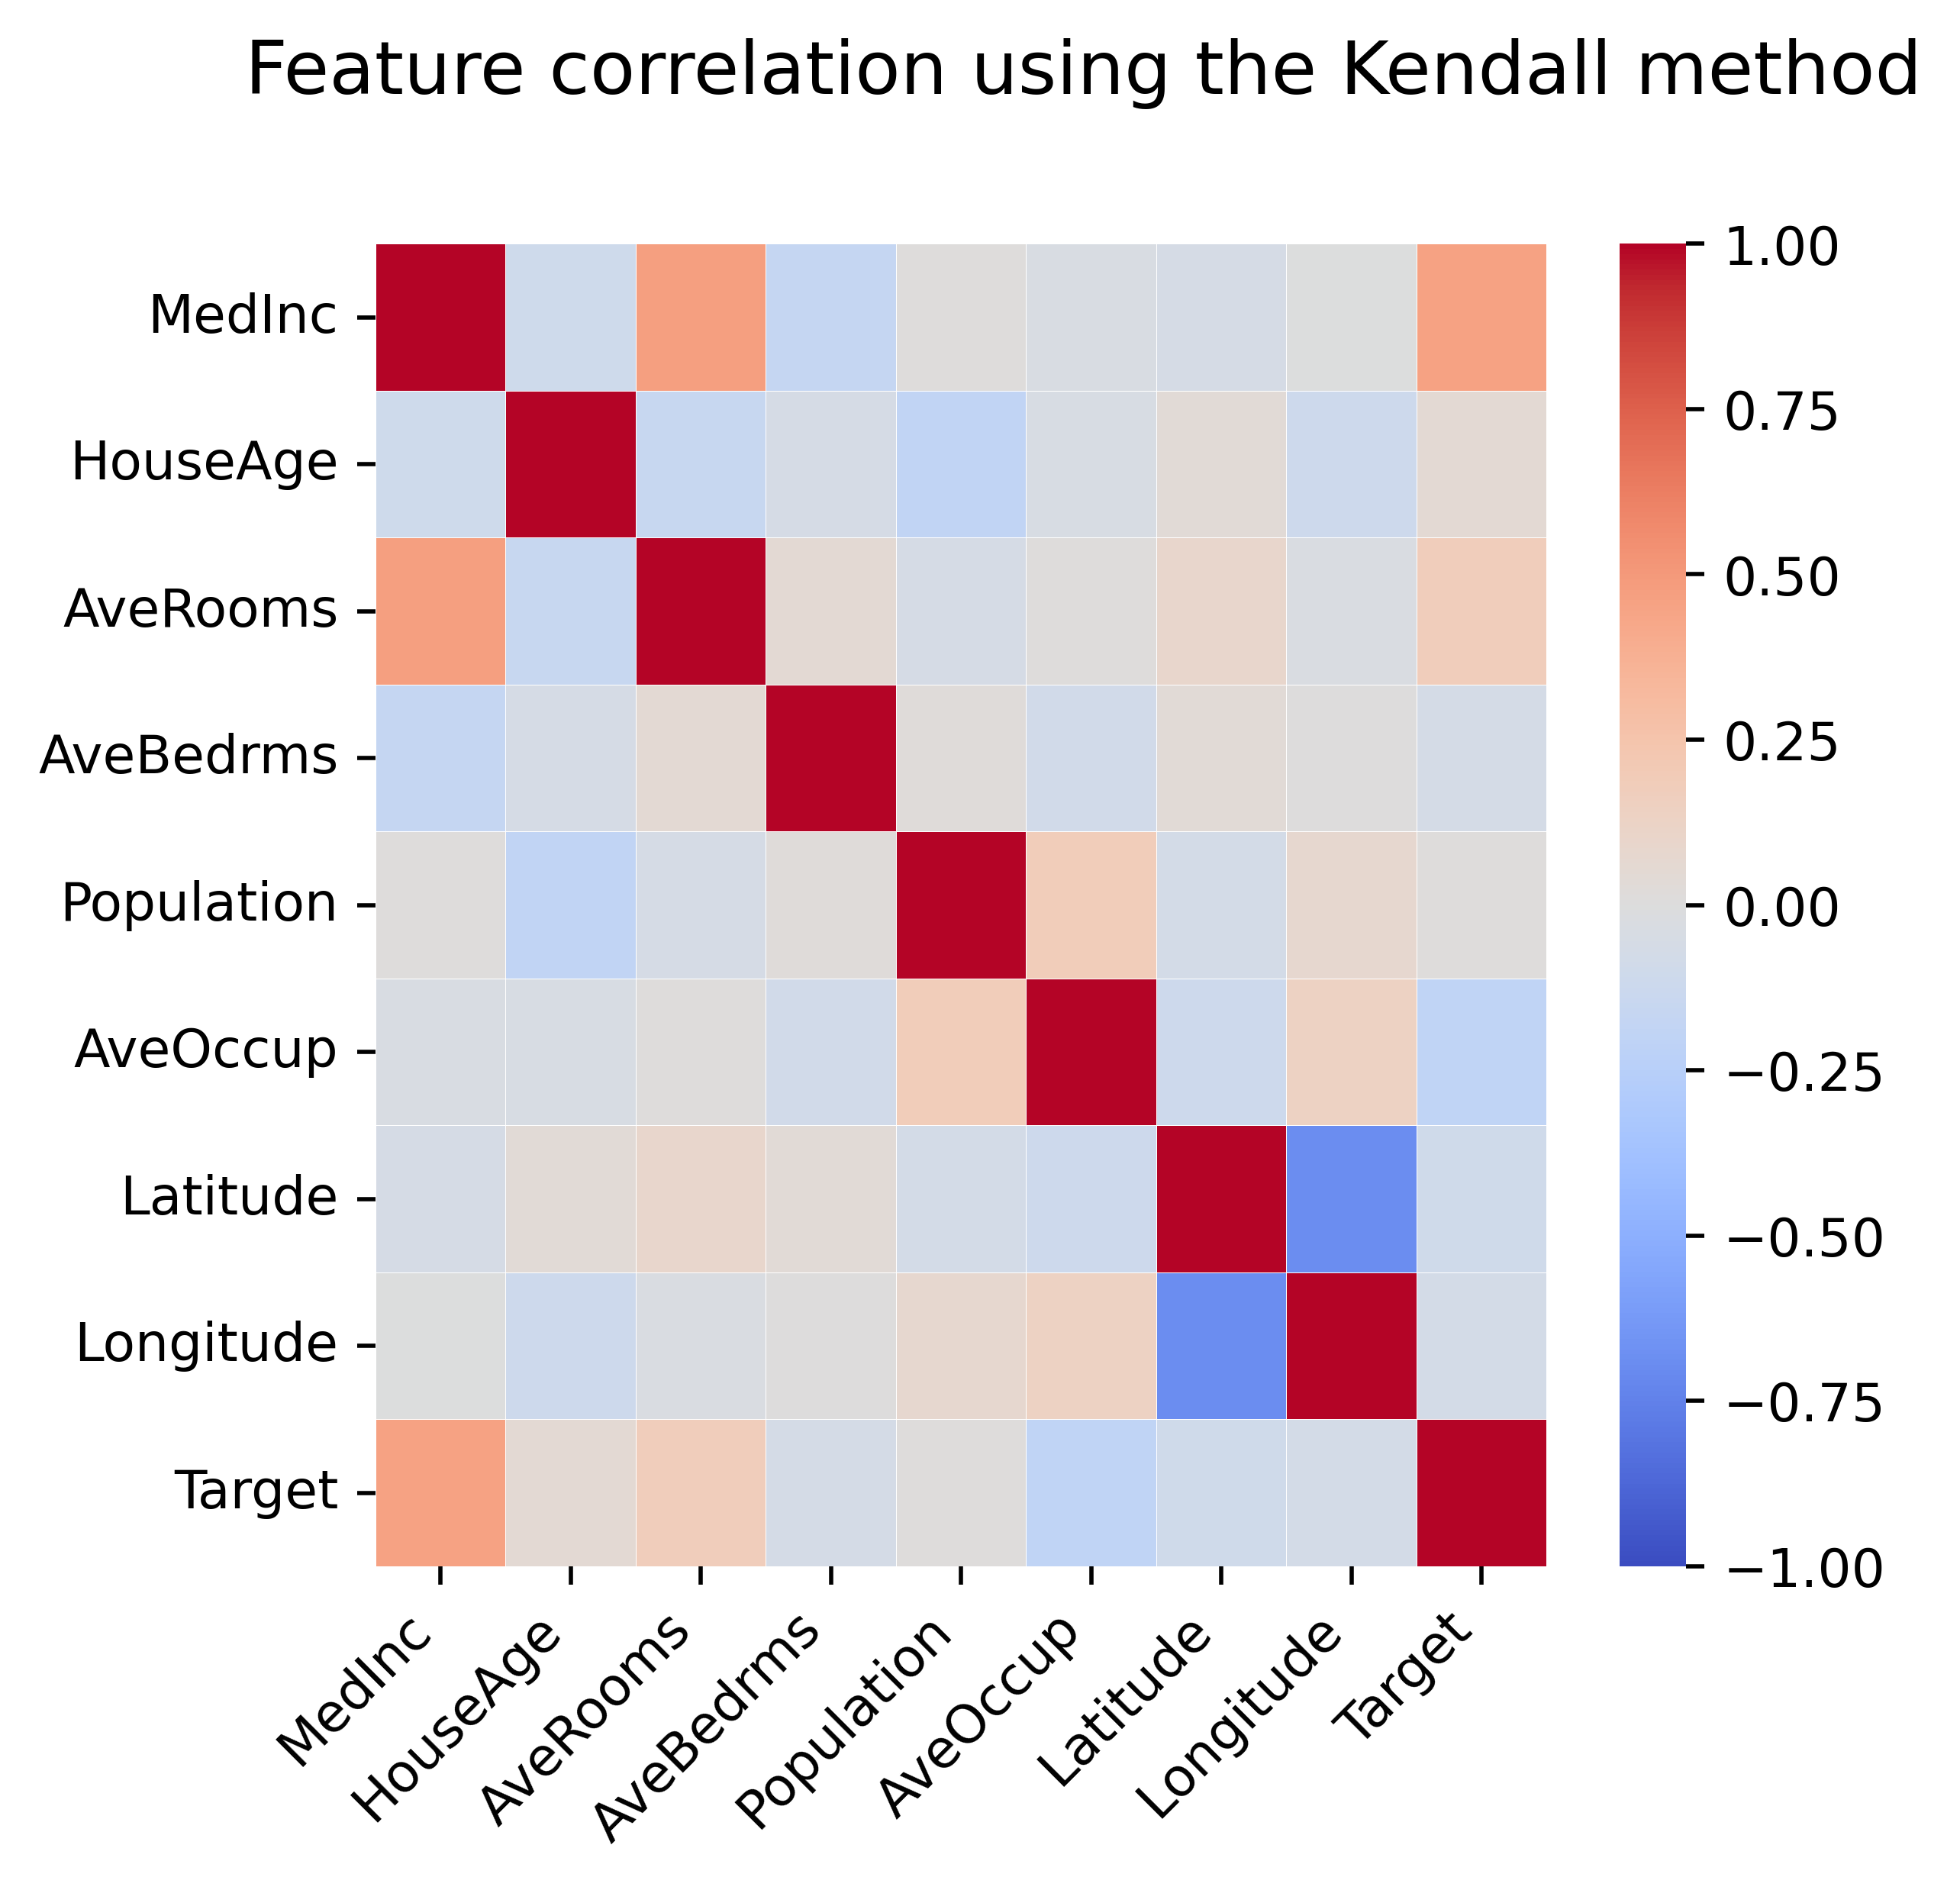

corr_vals without Nulls.shape (9, 9)


,Feature 1,Feature 2,absolute kendall correlation values


In [17]:
DataProfiler_obj.correlation_analysis(Xy_train, methods=['pearson', 'Kendall'],  groupby='Education', save_results=False)

###  Plot features

**Distribution Plot (distplot)** - The first thing you want to see when exploring your data is the distribution of your variables. 

**Example 1**: Plot histogram of one set of data

In [18]:
help(DataProfiler_obj.plot_hist)

Help on method plot_hist in module DataProfiler:

plot_hist(data, selected_features=None, joined_col_name='DataSet', save_results=True, groupby=None, bins=None, n_bins=None, n_quantiles=None, **plot_kwargs) method of DataProfiler.DataProfiler instance
    plots the histograms of data columns   
    
    Parameters
    ----------
    data : DataFrame object or dict
        a single dataframe object or a dictionary of some dataframes which will be concatenated. e.x. {'Train':Xy_train,'Test':Xy_test}
    
    joined_col_name : str, optional 
        if input data is dict, then this is the name of the new column added to the concatenated dataframes in the data. (default is "DataSet")
        this column would contain the names of the dataframes existing in the data. e.x. 'Train' label or 'Test' label
        
    selected_features : list, optional
        list of columns to be plotted. (default is None, so function will plot all columns)
    
    save_results : bool, optional 
        if s

c:\Users\parsa\Desktop\DataProfiler\Examples\..\DataProfiler.py:275: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gb = groupby_series.groupby(pd.cut(groupby_series, bins=n_bins))


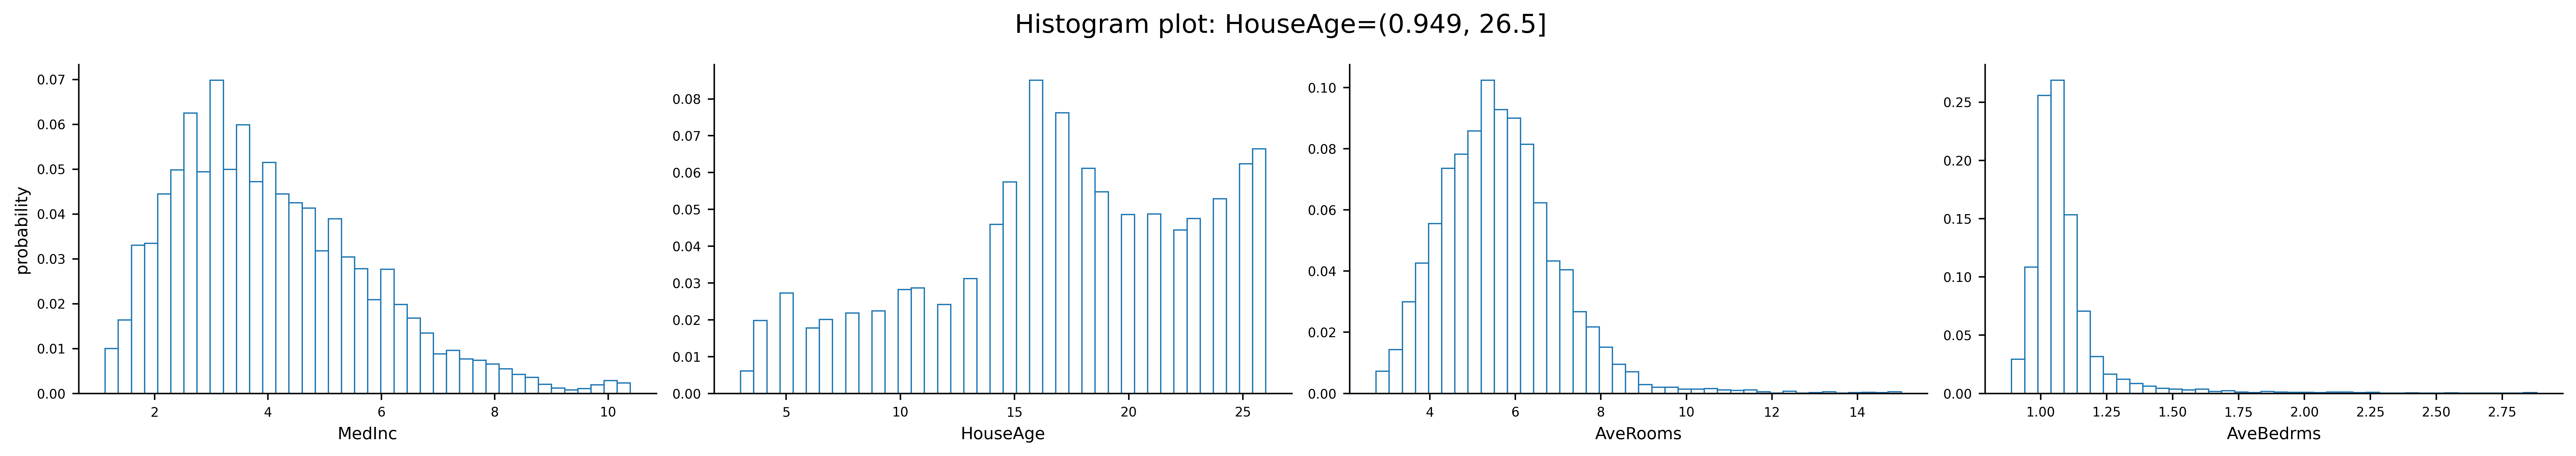

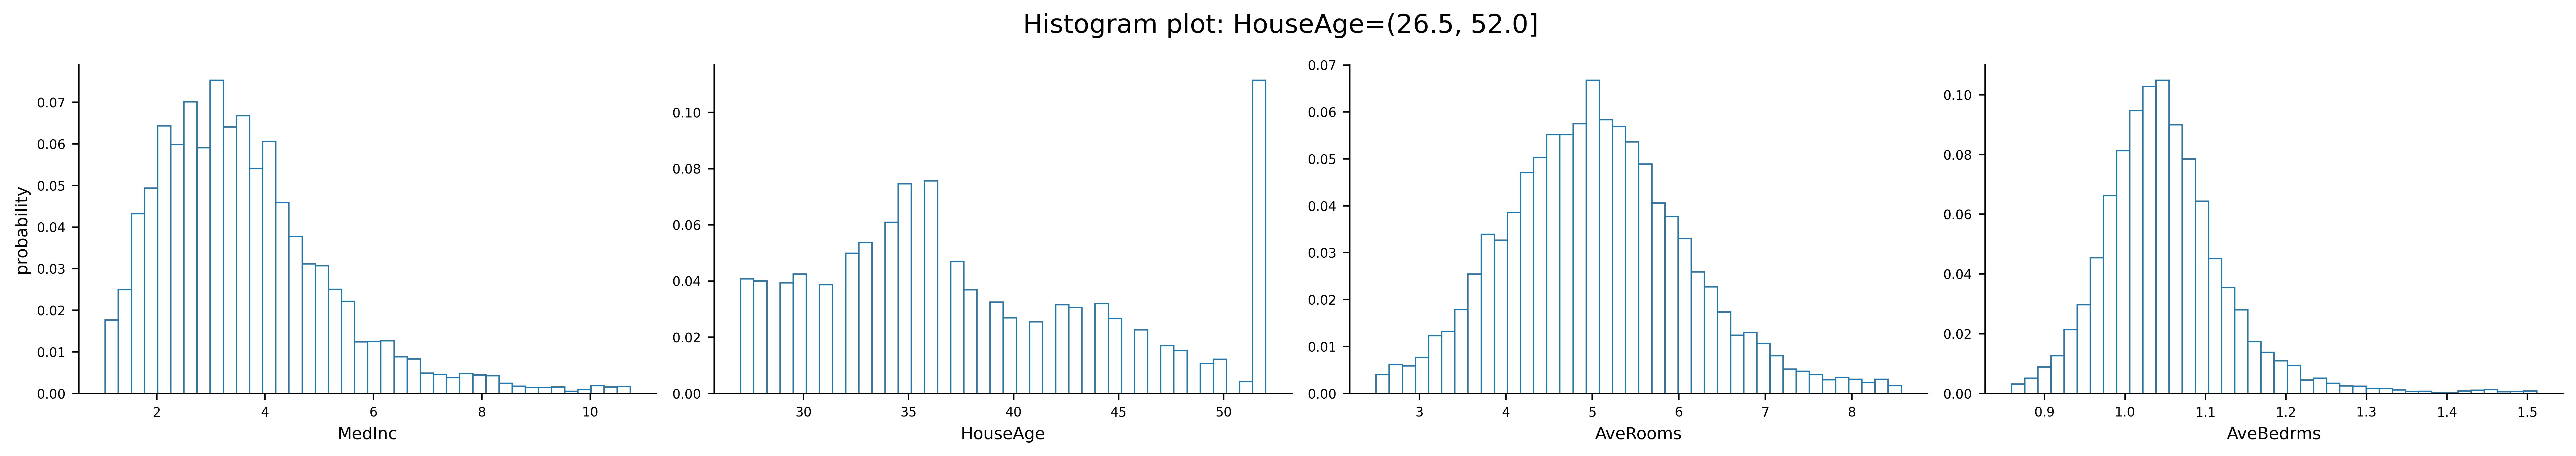

In [19]:
res = DataProfiler_obj.plot_hist(Xy_train, selected_features=feat_names[:4], groupby='HouseAge', 
                                 n_bins=2, element='bars', fill=False, n_cols=4, save_results=False)

**Example 2**: One set of data; but splitted based on `hul_col`

c:\Users\parsa\Desktop\DataProfiler\Examples\..\DataProfiler.py:273: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gb = groupby_series.groupby(pd.cut(groupby_series, bins=bins))


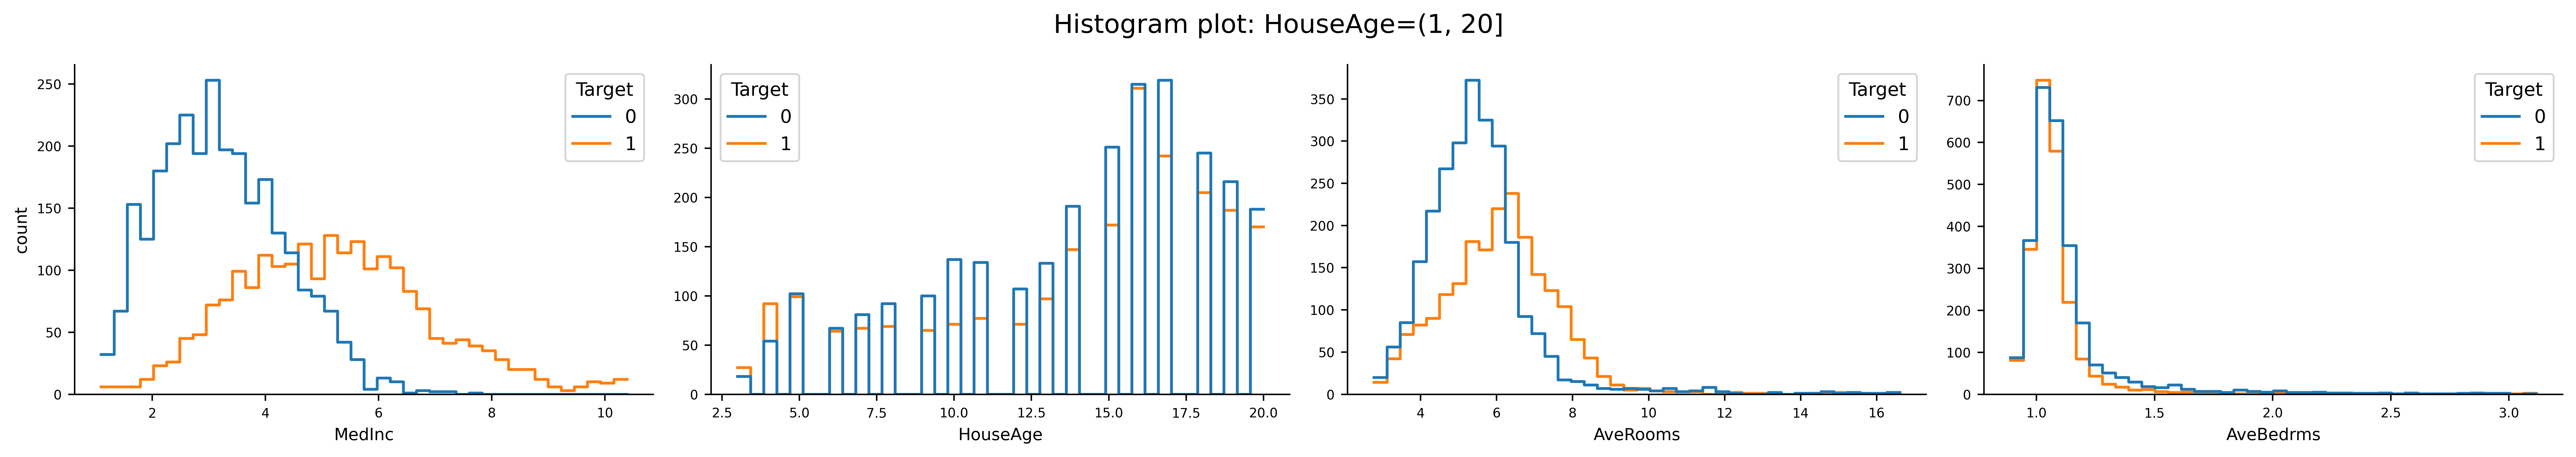

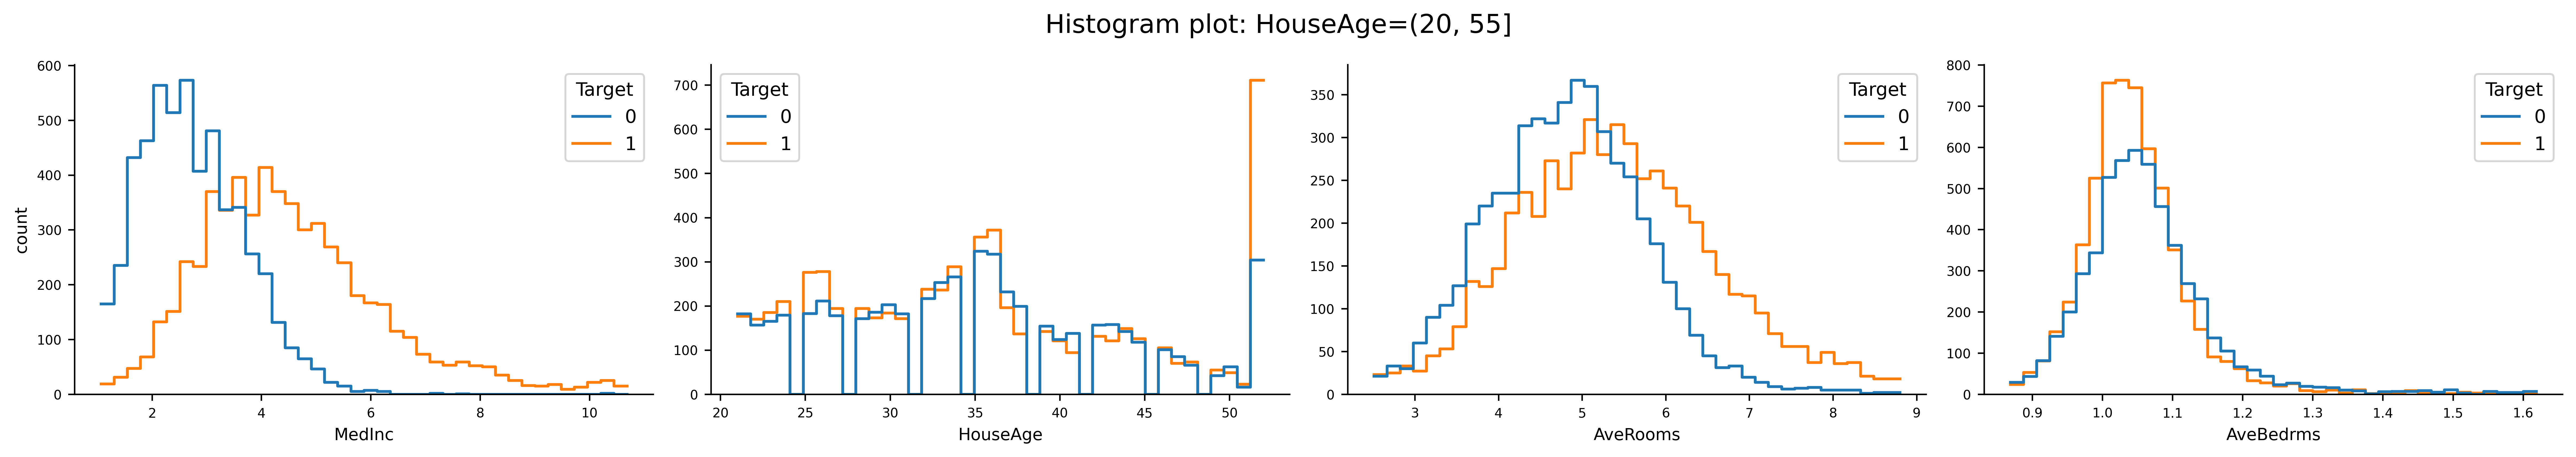

In [20]:
res = DataProfiler_obj.plot_hist(Xy_train, selected_features=feat_names[:4], groupby='HouseAge',
                                                   hue_col='Target', stat='count', bins=[(1, 20), (20, 55)], n_cols=4, save_results=False)

**Example 3**: Two sets of data and also splitted based on `hul_col`
*Important Note*: When there is more than one set of data, they will be metged

c:\Users\parsa\Desktop\DataProfiler\Examples\..\DataProfiler.py:273: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gb = groupby_series.groupby(pd.cut(groupby_series, bins=bins))


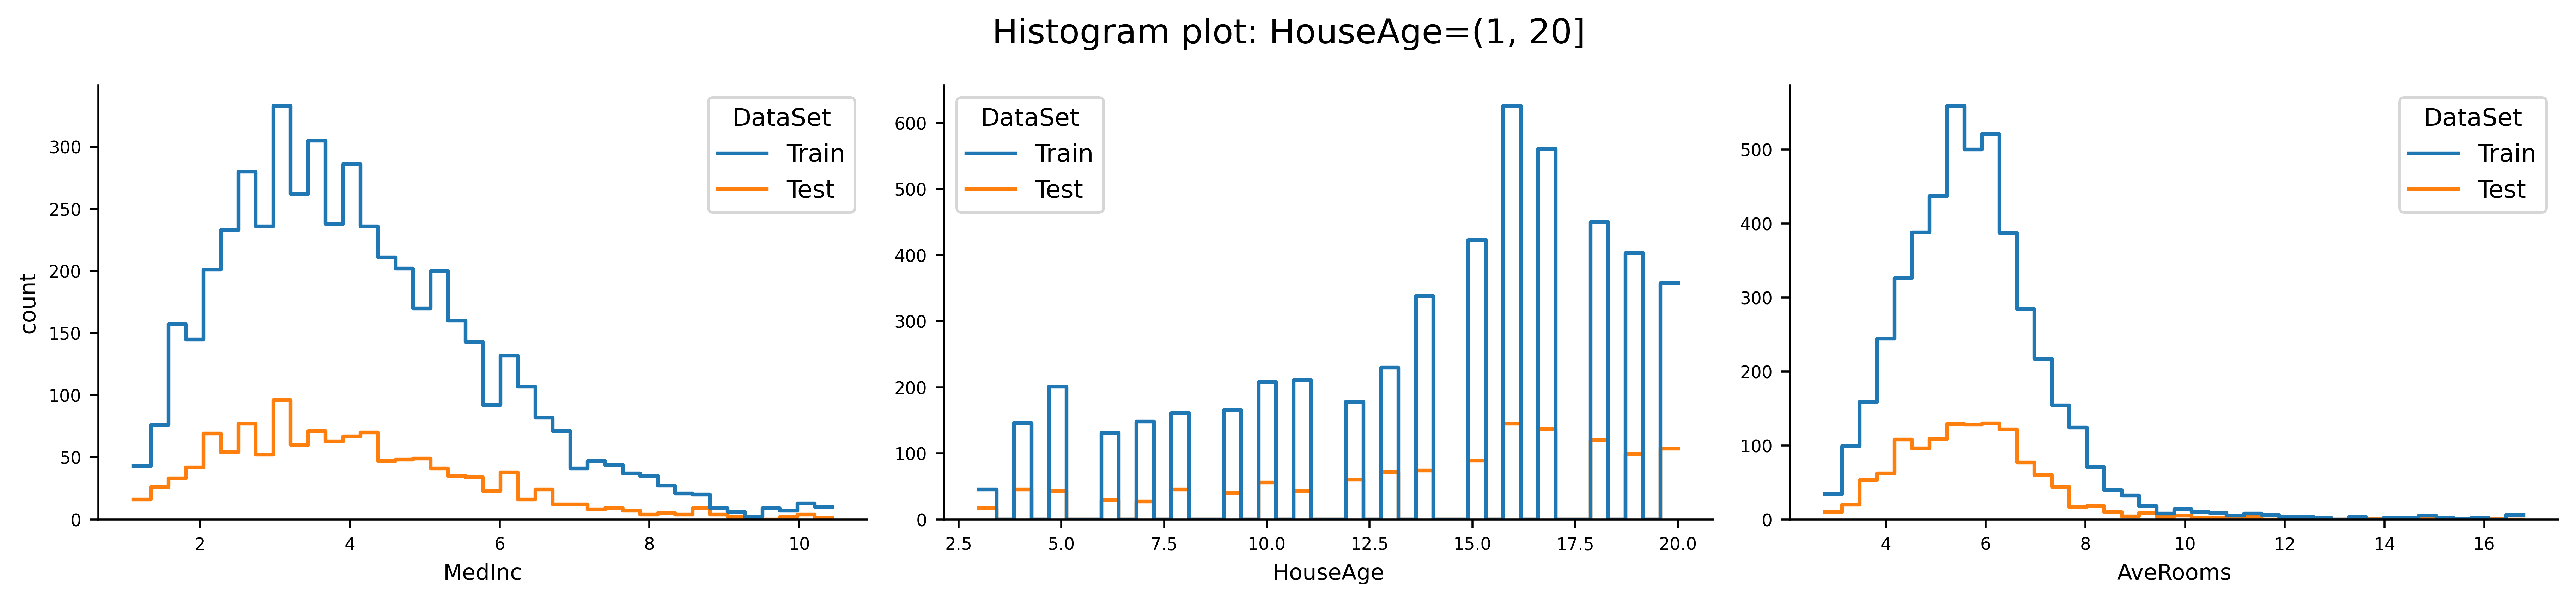

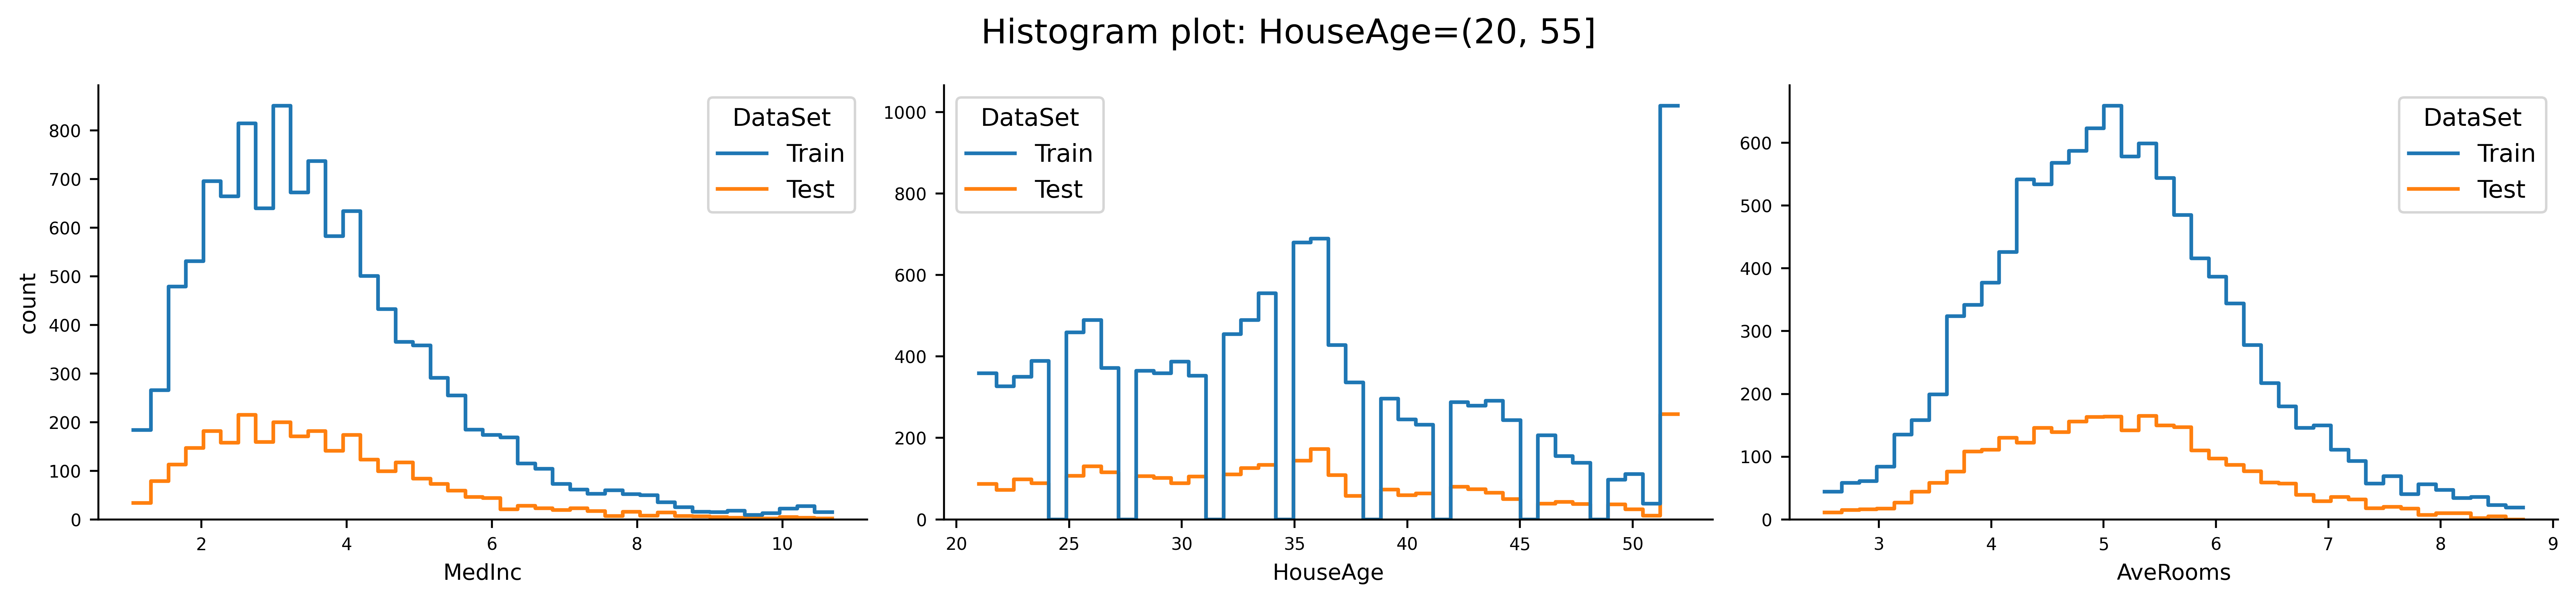

In [21]:
res= DataProfiler_obj.plot_hist({'Train':Xy_train,'Test':Xy_test}, selected_features=feat_names[:3], 
                                groupby='HouseAge',  bins=[(1, 20), (20, 55)],
                                n_cols=3, hue_col='DataSet', fill=False,
                                stat='count', 
                               )

### Outlier analysis

c:\Users\parsa\Desktop\DataProfiler\Examples\..\DataProfiler.py:273: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gb = groupby_series.groupby(pd.cut(groupby_series, bins=bins))


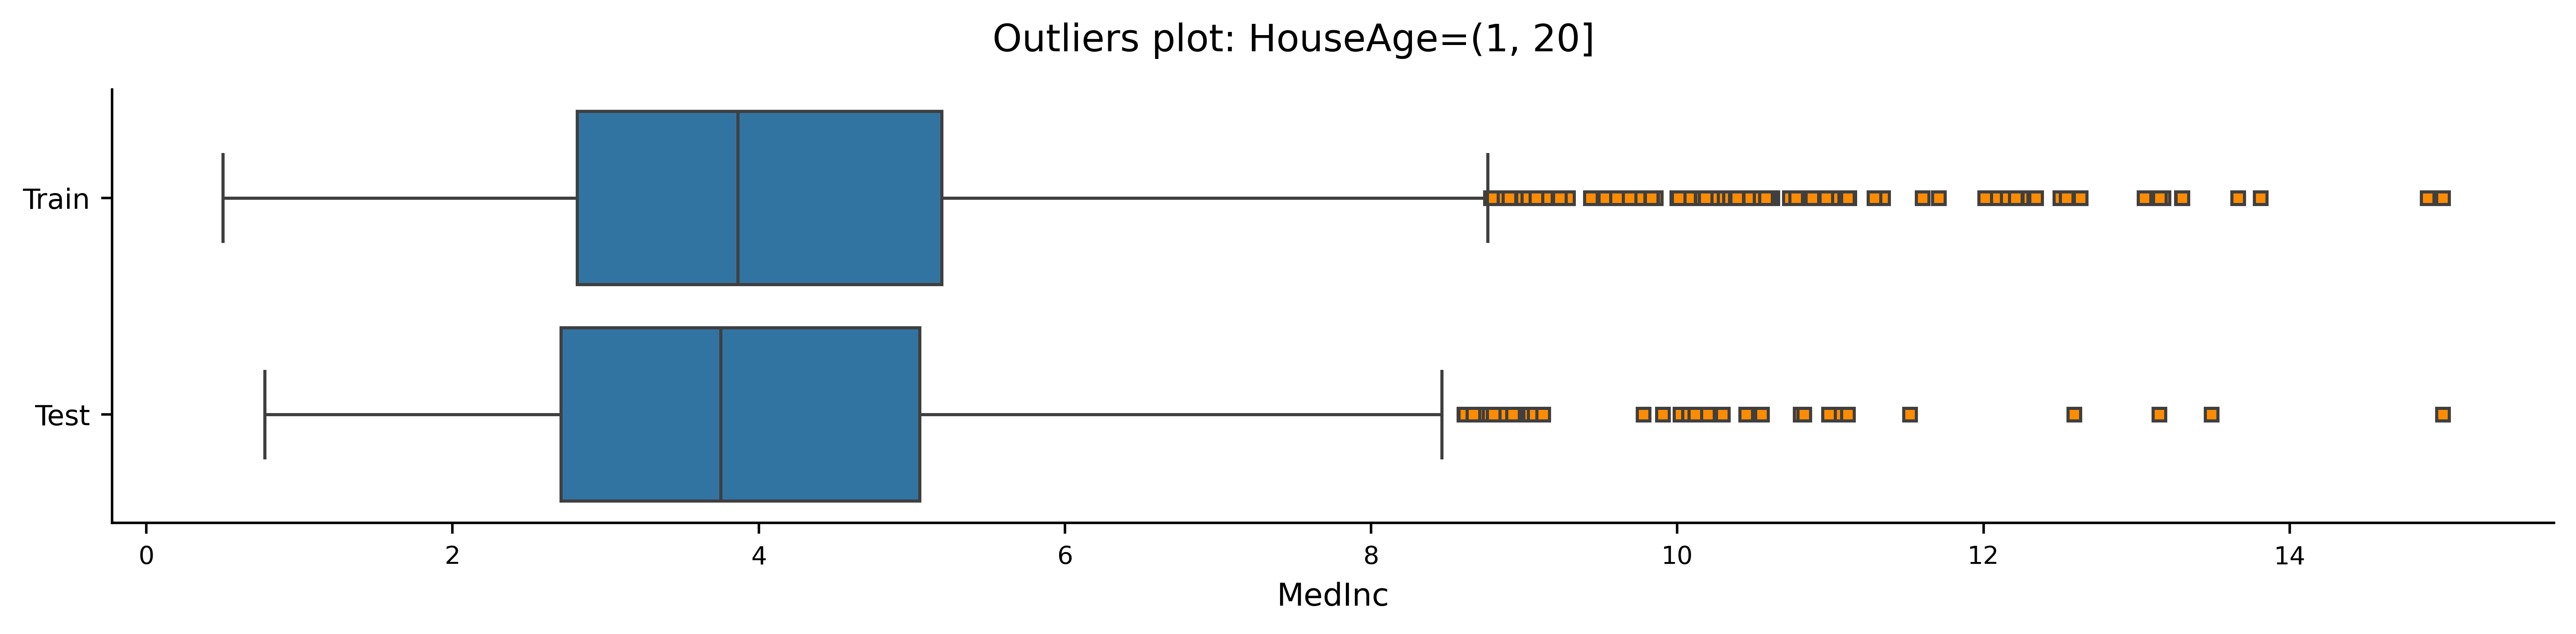

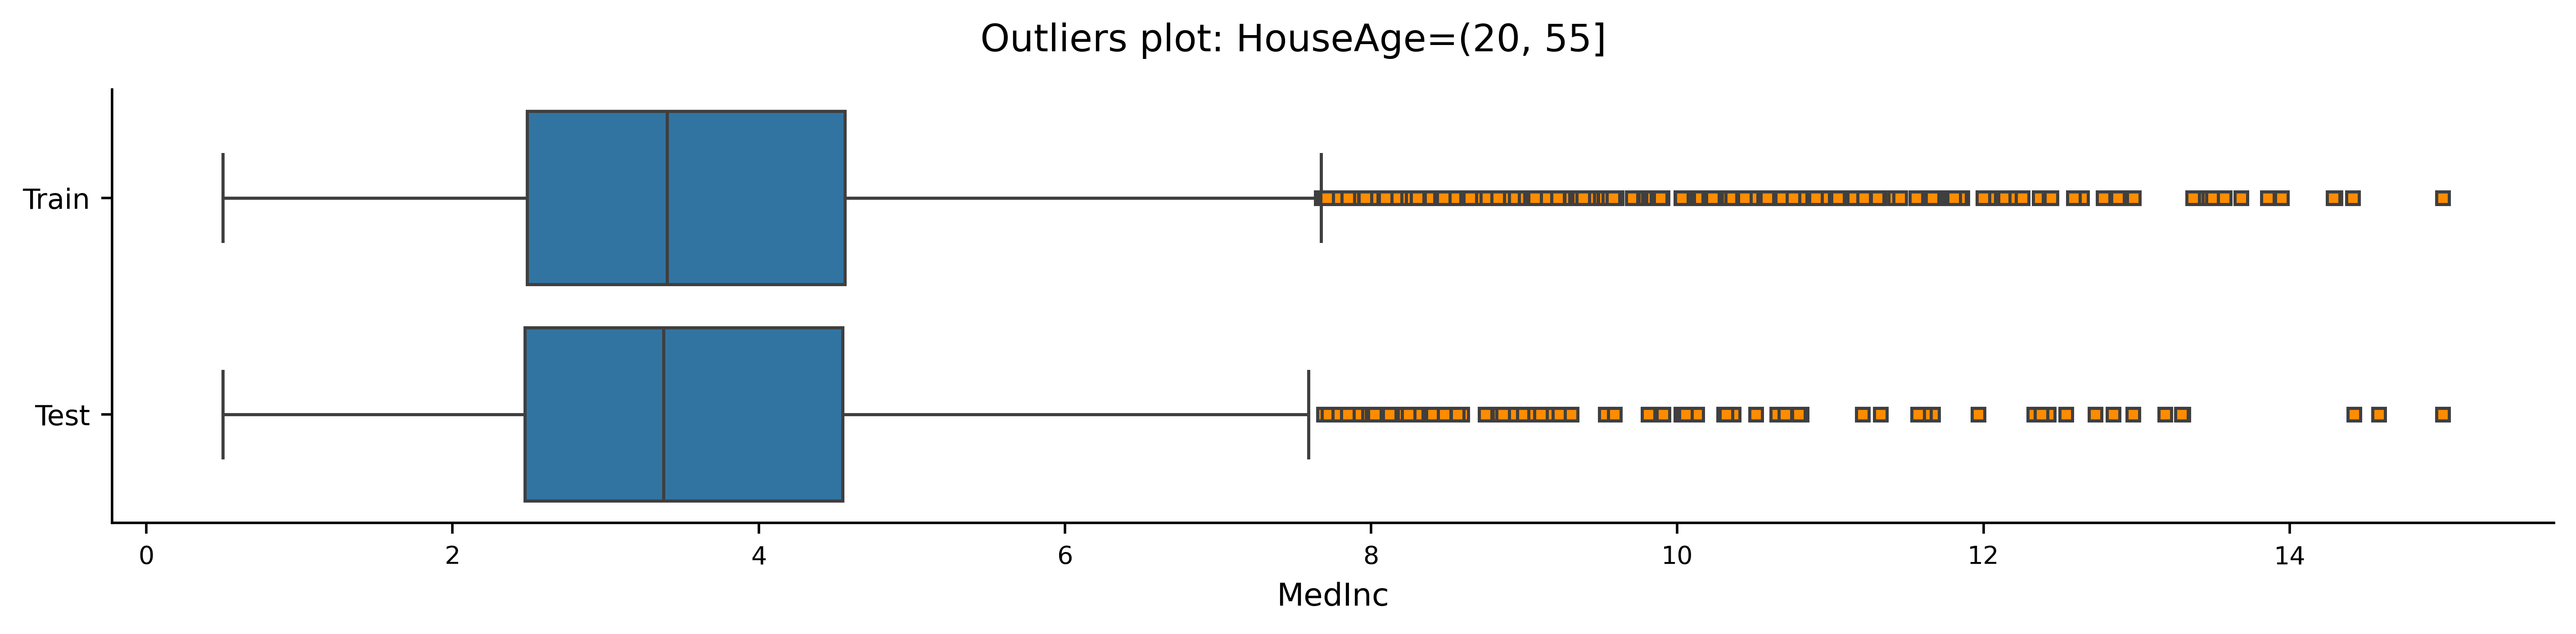

In [22]:
res = DataProfiler_obj.plot_outliers(data={'Train':Xy_train,'Test':Xy_test}, 
                                    selected_features=feat_names[:1], hue_col='DataSet',
                                    groupby='HouseAge', bins=[(1, 20), (20, 55)])

In [23]:
help(DataProfiler_obj.plot_outliers)

Help on method plot_outliers in module DataProfiler:

plot_outliers(data, selected_features=None, joined_col_name='DataSet', save_results=True, groupby=None, bins=None, n_bins=None, n_quantiles=None, **plot_kwargs) method of DataProfiler.DataProfiler instance
    plots the boxplots of columns   
    
    Parameters
    ----------
    data : DataFrame object or dict
        a single dataframe object or a dictionary of some dataframes which will be concatenated. e.x. {'Train':Xy_train,'Test':Xy_test}
    joined_col_name : str, optional 
        if input data is dict, then this is the name of the new column added to the concatenated dataframes in the data. (default is "DataSet")
        this column would contain the names of the dataframes existing in the data. e.x. 'Train' label or 'Test' label
    selected_features : list, optional
        list of columns to be plotted. (default is None, so function will plot all columns)
    
    save_results : bool, optional 
        if save_results i

**Transferring final results from Databricks driver which is a temporary storage to DBFS:**

In [24]:
# %sh
# cd Results_of_DataProfiling
# ls

In [25]:
# %sh
# cp -r Results_of_DataProfiling/ /dbfs/...../Examples/


Merging one hot encoded columns:

In [26]:
from DataProfiler import merge_one_hot_encoded_columns

OHE_features = {'Education':['Education_A', 'Education_B', 'Education_C'], 'Location':['Latitude', 'Longitude']}
Xy_train = merge_one_hot_encoded_columns(Xy_train, OHE_features='auto')
Xy_test = merge_one_hot_encoded_columns(Xy_test)

Xy_train.head(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Education,Target
0,1.4917,35,3.847291,0.992611,1587.0,3.908867,33.93,-118.26,C,0
1,0.5360,4,14.000000,3.333333,9.0,3.000000,34.14,-116.76,B,0
2,1.9125,36,3.332721,1.029412,1501.0,2.759191,34.14,-118.24,A,1
